## **Telco Customer Churn — Exploratory Data Analysis**

### 📊 Telco Customer Churn — Dataset Schema

**Rows:** ~7,043 · **Columns:** 33 · **Target:** `Churn Value` (`0` = Stayed, `1` = Churned)

| # | Column | Type | Description / Values |
|---|--------|------|------------------------|
| 1  | `CustomerID`        | string | Unique customer ID (e.g. `3668-QPYBK`) |
| 2  | `Count`             | int    | Record count, always `1` |
| 3  | `Country`           | string | Customer country |
| 4  | `State`             | string | Customer state |
| 5  | `City`              | string | Customer city |
| 6  | `Zip Code`          | int    | Postal code |
| 7  | `Lat Long`          | string | Combined `lat, long` |
| 8  | `Latitude`          | float  | Geographic latitude |
| 9  | `Longitude`         | float  | Geographic longitude |
| 10 | `Gender`            | string | `Male` / `Female` |
| 11 | `Senior Citizen`    | string | `Yes` / `No` |
| 12 | `Partner`           | string | `Yes` / `No` |
| 13 | `Dependents`        | string | `Yes` / `No` |
| 14 | `Tenure Months`     | int    | Months as customer (`1`–`72`) |
| 15 | `Phone Service`     | string | `Yes` / `No` |
| 16 | `Multiple Lines`    | string | `Yes` / `No` / `No phone service` |
| 17 | `Internet Service`  | string | `DSL` / `Fiber optic` / `No` |
| 18 | `Online Security`   | string | `Yes` / `No` / `No internet service` |
| 19 | `Online Backup`     | string | `Yes` / `No` / `No internet service` |
| 20 | `Device Protection` | string | `Yes` / `No` / `No internet service` |
| 21 | `Tech Support`      | string | `Yes` / `No` / `No internet service` |
| 22 | `Streaming TV`      | string | `Yes` / `No` / `No internet service` |
| 23 | `Streaming Movies`  | string | `Yes` / `No` / `No internet service` |
| 24 | `Contract`          | string | `Month-to-month` / `One year` / `Two year` |
| 25 | `Paperless Billing` | string | `Yes` / `No` |
| 26 | `Payment Method`    | string | `Electronic check` / `Mailed check` / `Bank transfer` / `Credit card` |
| 27 | `Monthly Charges`   | float  | `18.80`–`118.75` |
| 28 | `Total Charges`     | object⚠️ | `18.80`–`8684.80` — stored as string, must cast to `float` |
| 29 | `Churn Label`       | string | `Yes` / `No` |
| 30 | **`Churn Value`**   | int    | 🎯 **Target** — `0` = Stayed, `1` = Churned |
| 31 | `Churn Score`       | int    | ML-based churn probability score (`1`–`100`) |
| 32 | `CLTV`              | int    | Customer Lifetime Value (`2003`–`6500`) |
| 33 | `Churn Reason`      | string | Reason for churn ⚠️ **5,174 nulls** (only set for churned customers) |

> ⚠️ **Watch out for:** `Total Charges` needs type conversion (object → float); `Churn Reason` is mostly null (non-churned customers have no reason).
> 💡 Use `Churn Value` as the ML target — `Churn Label`/`Churn Score` would leak the target.

### **1. Setup & Configuration**

In First part Fix setup & cinfiguration that will be used in future sections of jupyter notebook.

In [70]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import matplotlib.gridspec as gridspec
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats
import joblib
import warnings
import optuna

import mlflow
import mlflow.sklearn
import mlflow.xgboost
import mlflow.lightgbm
import time
import json
from datetime import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report
)
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder, MinMaxScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline as SkiPipeline

import xgboost as xgb
import lightgbm as lgb
import catboost as cb

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)

plt.rcParams.update({
    'figure.dpi': 120,
    'figure.facecolor': 'white',
    'axes.facecolor': '#f8f9fa',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.titleweight': 'bold',
    'axes.labelsize': 12,
})
sns.set_style('whitegrid')

C_RETAIN  = '#2ecc71'
C_CHURN   = '#e74c3c'
C_PRIMARY = '#3498db'
C_ACCENT  = '#f39c12'
C_PURPLE  = '#9b59b6'
C_TEAL    = '#1abc9c'
CHURN_MAP = {'No': C_RETAIN, 'Yes': C_CHURN}
PALETTE_7 = [C_PRIMARY, C_CHURN, C_RETAIN, C_ACCENT, C_PURPLE, C_TEAL, '#e67e22']


In [4]:
df = pd.read_excel('../data/v1/Telco_customer_churn.xlsx')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
print(f'Memory usage: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df.head(3)

Loaded: 7,043 rows x 33 columns
Memory usage: 9.8 MB


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved


In [6]:
## Dataset Overview
print(f"Rows    : {df.shape[0]}")
print(f"Columns : {df.shape[1]}")

display(df.sample(3))

Rows    : 7043
Columns : 33


,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
4733,7995-ZHHNZ,1,United States,California,Fullerton,92832,"33.868316, -117.929029",33.868316,-117.929029,Male,No,Yes,No,42,Yes,Yes,DSL,Yes,No,No,No,No,No,One year,No,Credit card (automatic),56.10,2386.85,No,0,69,5904,NaN
1604,3945-GFWQL,1,United States,California,San Jose,95113,"37.333851, -121.891147",37.333851,-121.891147,Female,No,No,Yes,12,Yes,No,DSL,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,44.55,480.6,Yes,1,89,4162,Extra data charges
1298,3217-FZDMN,1,United States,California,Los Angeles,90001,"33.973616, -118.24902",33.973616,-118.249020,Female,Yes,No,No,8,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Credit card (automatic),94.45,742.95,Yes,1,83,3676,Service dissatisfaction


### **Data Quality Audit**  
In this block I generate a summary DataFrame (`overview`) to assess column-level data health.  
It captures data types, non-null counts, missing values (count & percentage), unique value counts, and memory usage per column.  
These metrics help identify columns with high null rates, incorrect dtypes, or excessive memory consumption for further cleaning and optimization.

In [7]:
# Column overview
overview = pd.DataFrame({
    'Dtype'      : df.dtypes.astype(str),
    'Non-Null'   : df.notna().sum(),
    'Null Count' : df.isna().sum(),
    'Null %'     : (df.isna().sum() / len(df) * 100).round(2),
    'Unique'     : df.nunique(),
    'Memory (KB)': (df.memory_usage(deep=True) / 1024).round(1),
})
overview

,Dtype,Non-Null,Null Count,Null %,Unique,Memory (KB)
CLTV,int64,7043.0,0.0,0.00,3438.0,55.0
Churn Label,object,7043.0,0.0,0.00,2.0,352.6
Churn Reason,object,1869.0,5174.0,73.46,20.0,297.1
Churn Score,int64,7043.0,0.0,0.00,85.0,55.0
Churn Value,int64,7043.0,0.0,0.00,2.0,55.0
City,object,7043.0,0.0,0.00,1129.0,400.5
Contract,object,7043.0,0.0,0.00,3.0,414.7
Count,int64,7043.0,0.0,0.00,1.0,55.0
Country,object,7043.0,0.0,0.00,1.0,426.4
CustomerID,object,7043.0,0.0,0.00,7043.0,405.8


**Data Quality Assessment**

The dataset contains 7,043 records with no missing values across all columns except `Churn Reason`, which has 5,174 null entries (73.46%). This is structurally valid as the column is only populated for customers who have churned.

**Memory Optimization Opportunities**

Categorical columns (`object` dtype) consume significantly more memory than numerical columns. For example, `Contract` (414.7 KB) and `Country` (426.4 KB) use nearly 8x more memory than integer columns like `CLTV` (55.0 KB), despite having only 3 and 1 unique values respectively. Converting these to `category` dtype can drastically reduce memory usage.

**High-Cardinality Columns**

Several columns contain nearly unique values per row, including `CustomerID` (7,043 unique), `Total Charges` (6,531 unique), and `Lat Long` (1,652 unique). While `CustomerID` serves as a record identifier, high-cardinality features like `Total Charges` and `Lat Long` may require special handling for modeling.

**Key Observations:**

- Only 1 column has missing values (`Churn Reason`: 73.46% null)
- Object columns dominate memory usage despite low cardinality
- 8 columns have 2 unique values (binary categorical)
- `Count` and `Country` have only 1 unique value (potential drop candidates)
- Coordinates (`Latitude`/`Longitude`) are stored separately and as combined `Lat Long` (redundant)

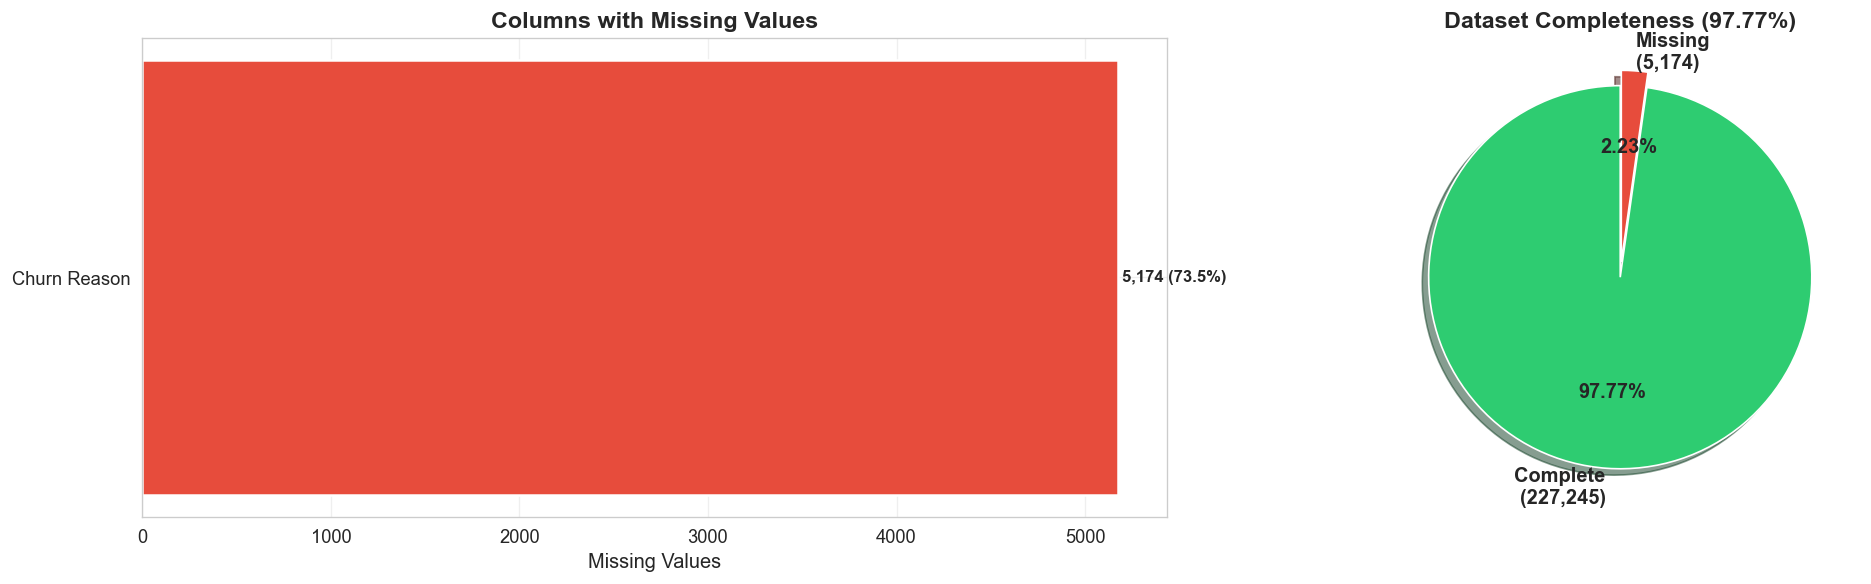

In [6]:
# Null heatmap
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

# Left: null count bar chart
null_cols = df.isnull().sum()
null_cols = null_cols[null_cols > 0].sort_values(ascending=True)
if len(null_cols) > 0:
    colors_bar = [C_CHURN if v / len(df) > 0.5 else C_ACCENT for v in null_cols.values]
    axes[0].barh(null_cols.index, null_cols.values, color=colors_bar, edgecolor='white', linewidth=1.5)
    for i, (val, col) in enumerate(zip(null_cols.values, null_cols.index)):
        pct = val / len(df) * 100
        axes[0].text(val + 20, i, f'{val:,} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')
    axes[0].set_xlabel('Missing Values')
    axes[0].set_title('Columns with Missing Values', fontweight='bold')
else:
    axes[0].text(0.5, 0.5, 'No missing values found!', transform=axes[0].transAxes,
                 ha='center', va='center', fontsize=16, color=C_RETAIN)
    axes[0].set_title('Missing Values Audit', fontweight='bold')

# Right: overall completeness
total_cells = df.shape[0] * df.shape[1]
total_missing = df.isnull().sum().sum()
complete_cells = total_cells - total_missing
completeness = complete_cells / total_cells * 100

axes[1].pie([complete_cells, total_missing],
            labels=[f'Complete\n({complete_cells:,})', f'Missing\n({total_missing:,})'],
            colors=[C_RETAIN, C_CHURN], autopct='%1.2f%%', startangle=90,
            explode=(0, 0.08), shadow=True, textprops={'fontsize': 12, 'fontweight': 'bold'})
axes[1].set_title(f'Dataset Completeness ({completeness:.2f}%)', fontweight='bold')

plt.tight_layout()
plt.show()

In [7]:
# Data type fixes
print('Before conversion:')
print(f"  Total Charges dtype: {df['Total Charges'].dtype}")
print(f"  Total Charges nulls: {df['Total Charges'].isnull().sum()}")
print(f"  Sample non-numeric: {df[df['Total Charges'].apply(lambda x: isinstance(x, str) and not x.replace('.','').isdigit())]['Total Charges'].unique()[:5]}")

df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')

print(f'\nAfter conversion:')
print(f"  Total Charges dtype: {df['Total Charges'].dtype}")
print(f"  Total Charges nulls: {df['Total Charges'].isnull().sum()}")
print(f"  New nulls introduced: {df['Total Charges'].isnull().sum()} (customers with 0 tenure)")

Before conversion:
  Total Charges dtype: object
  Total Charges nulls: 0
  Sample non-numeric: [' ']

After conversion:
  Total Charges dtype: float64
  Total Charges nulls: 11
  New nulls introduced: 11 (customers with 0 tenure)


In [8]:
df[df['Total Charges'].isnull()].head(3)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
2234,4472-LVYGI,1,United States,California,San Bernardino,92408,"34.084909, -117.258107",34.084909,-117.258107,Female,No,Yes,No,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No,0,36,2578,NaN
2438,3115-CZMZD,1,United States,California,Independence,93526,"36.869584, -118.189241",36.869584,-118.189241,Male,No,No,No,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No,0,68,5504,NaN
2568,5709-LVOEQ,1,United States,California,San Mateo,94401,"37.590421, -122.306467",37.590421,-122.306467,Female,No,Yes,No,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No,0,45,2048,NaN


The `Total Charges` column was stored as a string and has been converted to numeric. This conversion introduced 11 null rows. Two approaches could be taken: dropping the rows or imputing values (e.g., mean). Given the dataset size, these 11 rows are negligible (~0.16%) and will simply be dropped.

In [9]:
# Constant & duplicate column detection
print('=== Constant Columns (1 unique value) ===')
const_cols = [c for c in df.columns if df[c].nunique() == 1]
for c in const_cols:
    print(f'  {c:20s} -> {df[c].unique()[0]}')

print(f'\n=== Duplicate Rows: {df.duplicated().sum()} ===')
print(f'\n=== Duplicate CustomerIDs: {df.duplicated(subset=["CustomerID"]).sum()} ===')

print(f'\n=== Near-Duplicate Detection ===')
print(f"  'Churn Label' == 'Churn Value' mapping check:",
      (df['Churn Label'] == df['Churn Value'].map({0: 'No', 1: 'Yes'})).all())

=== Constant Columns (1 unique value) ===
  Count                -> 1
  Country              -> United States
  State                -> California

=== Duplicate Rows: 0 ===

=== Duplicate CustomerIDs: 0 ===

=== Near-Duplicate Detection ===
  'Churn Label' == 'Churn Value' mapping check: True


Three constant columns were identified (`Count`, `Country`, `State`) containing only one unique value each. These columns provide no predictive value and can be safely dropped.

No duplicate rows were found in the dataset, and no duplicate `CustomerID` values exist, confirming each record is unique.

A redundancy check revealed that `Churn Label` and `Churn Value` contain identical information, making one of them redundant for modeling purposes.

#### Potential Target Leakage

In [10]:
leakage_cols = [
    "Churn Label",
    "Churn Value",
    "CLTV",
    "Churn Score",
    "Churn Reason"
]

df[leakage_cols].sample(3)

,Churn Label,Churn Value,CLTV,Churn Score,Churn Reason
7041,No,0,2793,59,NaN
5002,No,0,4108,37,NaN
4069,No,0,5421,52,NaN


These variables contain information generated after the churn event and therefore must not be used during model training. They are retained only for exploratory analysis and will be removed during preprocessing.

### **3. Column Classification**


In [11]:
COL_GROUPS = {
    'ID'         : ['CustomerID'],
    'Constant'    : ['Count', 'Country', 'State'],
    'Geographic'  : ['City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude'],
    'Demographics': ['Gender', 'Senior Citizen', 'Partner', 'Dependents'],
    'Services'    : ['Phone Service', 'Multiple Lines', 'Internet Service',
                     'Online Security', 'Online Backup', 'Device Protection',
                     'Tech Support', 'Streaming TV', 'Streaming Movies'],
    'Account'     : ['Contract', 'Paperless Billing', 'Payment Method'],
    'Financial'   : ['Tenure Months', 'Monthly Charges', 'Total Charges'],
    'Target'      : ['Churn Label', 'Churn Value', 'Churn Score', 'CLTV'],
    'Post-Hoc'    : ['Churn Reason'],
}

print('Column Groups:')
for group, cols in COL_GROUPS.items():
    print(f'  {group:15s}: {len(cols)} columns -> {cols}')

# Separate feature types
NUMERIC_COLS = ['Tenure Months', 'Monthly Charges', 'Total Charges']
BINARY_COLS = [c for c in df.columns if df[c].nunique() == 2 and c not in ['Churn Value', 'Count']]
MULTICAT_COLS = [c for c in df.columns if 2 < df[c].nunique() <= 10 and c not in NUMERIC_COLS]
HIGH_CARD_COLS = [c for c in df.columns if df[c].nunique() > 10 and c not in NUMERIC_COLS + ['Churn Reason']]

print(f'\nNumeric features       : {len(NUMERIC_COLS)} columns')
print(f'Binary features        : {len(BINARY_COLS)} columns')
print(f'Multi-categorical      : {len(MULTICAT_COLS)} columns')
print(f'High-cardinality       : {len(HIGH_CARD_COLS)} columns')

Column Groups:
  ID             : 1 columns -> ['CustomerID']
  Constant       : 3 columns -> ['Count', 'Country', 'State']
  Geographic     : 5 columns -> ['City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude']
  Demographics   : 4 columns -> ['Gender', 'Senior Citizen', 'Partner', 'Dependents']
  Services       : 9 columns -> ['Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']
  Account        : 3 columns -> ['Contract', 'Paperless Billing', 'Payment Method']
  Financial      : 3 columns -> ['Tenure Months', 'Monthly Charges', 'Total Charges']
  Target         : 4 columns -> ['Churn Label', 'Churn Value', 'Churn Score', 'CLTV']
  Post-Hoc       : 1 columns -> ['Churn Reason']

Numeric features       : 3 columns
Binary features        : 7 columns
Multi-categorical      : 10 columns
High-cardinality       : 8 columns


The dataset comprises 33 columns organized into 9 logical groups, including identifiers, constant values, geographic data, demographics, services, account details, financial metrics, target variables, and post-hoc churn reasons. Feature types are diverse, with 3 numeric, 7 binary, 10 multi-categorical, and 8 high-cardinality columns, indicating the need for appropriate encoding and dimensionality reduction strategies. Constant columns (`Count`, `Country`, `State`) provide no predictive value and should be dropped, while high-cardinality features like `City` and `Zip Code` may require special handling such as frequency encoding or clustering.

### **4. Target Variable Analysis**

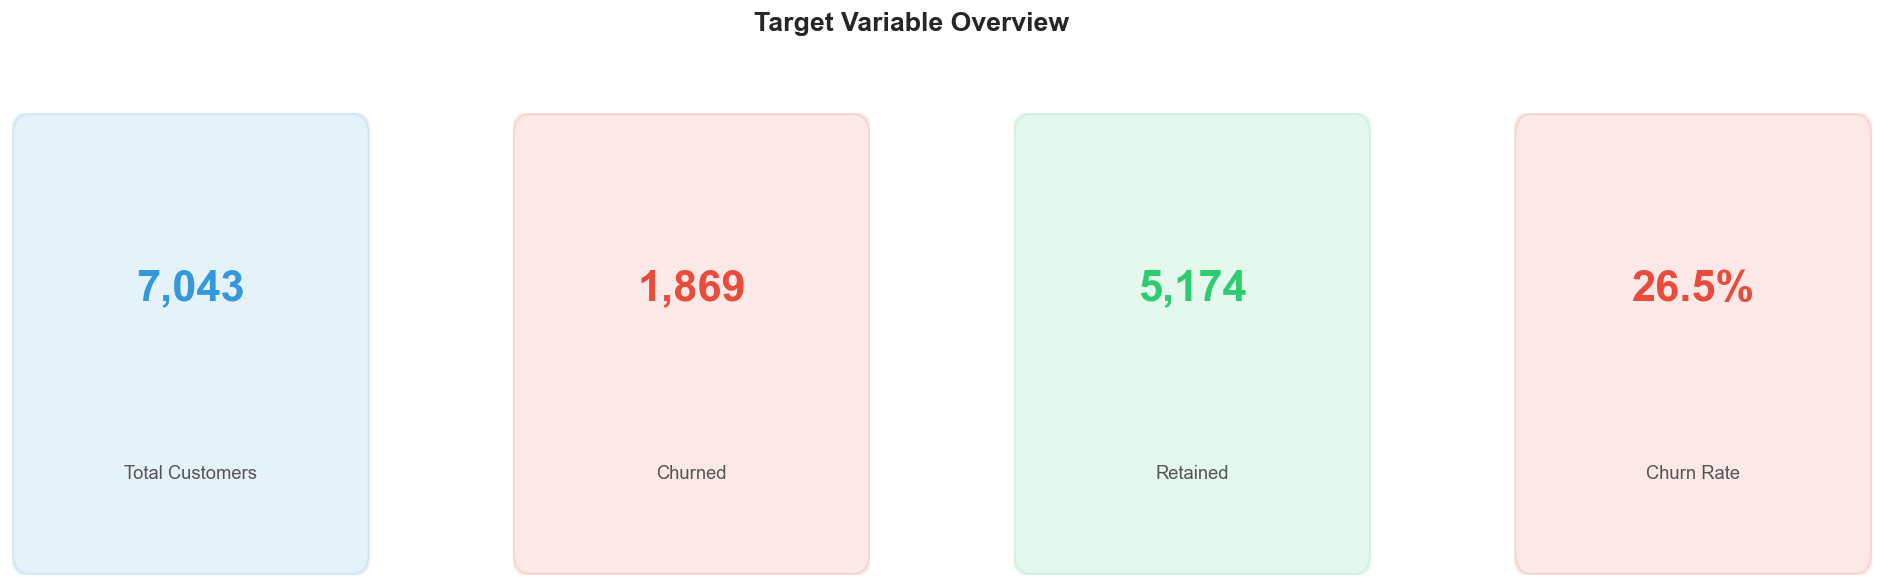

In [12]:
churn_counts = df['Churn Label'].value_counts()
churn_rate = churn_counts['Yes'] / len(df) * 100
retention_rate = 100 - churn_rate

fig = plt.figure(figsize=(20, 5))
gs = gridspec.GridSpec(1, 4, figure=fig, wspace=0.4)

# KPI cards
kpis = [
    ('Total Customers', f'{len(df):,}', C_PRIMARY),
    ('Churned', f'{churn_counts["Yes"]:,}', C_CHURN),
    ('Retained', f'{churn_counts["No"]:,}', C_RETAIN),
    ('Churn Rate', f'{churn_rate:.1f}%', C_CHURN),
]
for i, (label, value, color) in enumerate(kpis):
    ax = fig.add_subplot(gs[0, i])
    ax.add_patch(mpatches.FancyBboxPatch((0.05, 0.05), 0.9, 0.9, transform=ax.transAxes,
               boxstyle='round,pad=0.05', facecolor=color, alpha=0.12, edgecolor=color, linewidth=2.5))
    ax.text(0.5, 0.62, value, transform=ax.transAxes, ha='center', va='center',
            fontsize=26, fontweight='bold', color=color)
    ax.text(0.5, 0.22, label, transform=ax.transAxes, ha='center', va='center',
            fontsize=11, color='#555')
    ax.axis('off')

fig.suptitle('Target Variable Overview', fontsize=16, fontweight='bold', y=1.05)
plt.show()

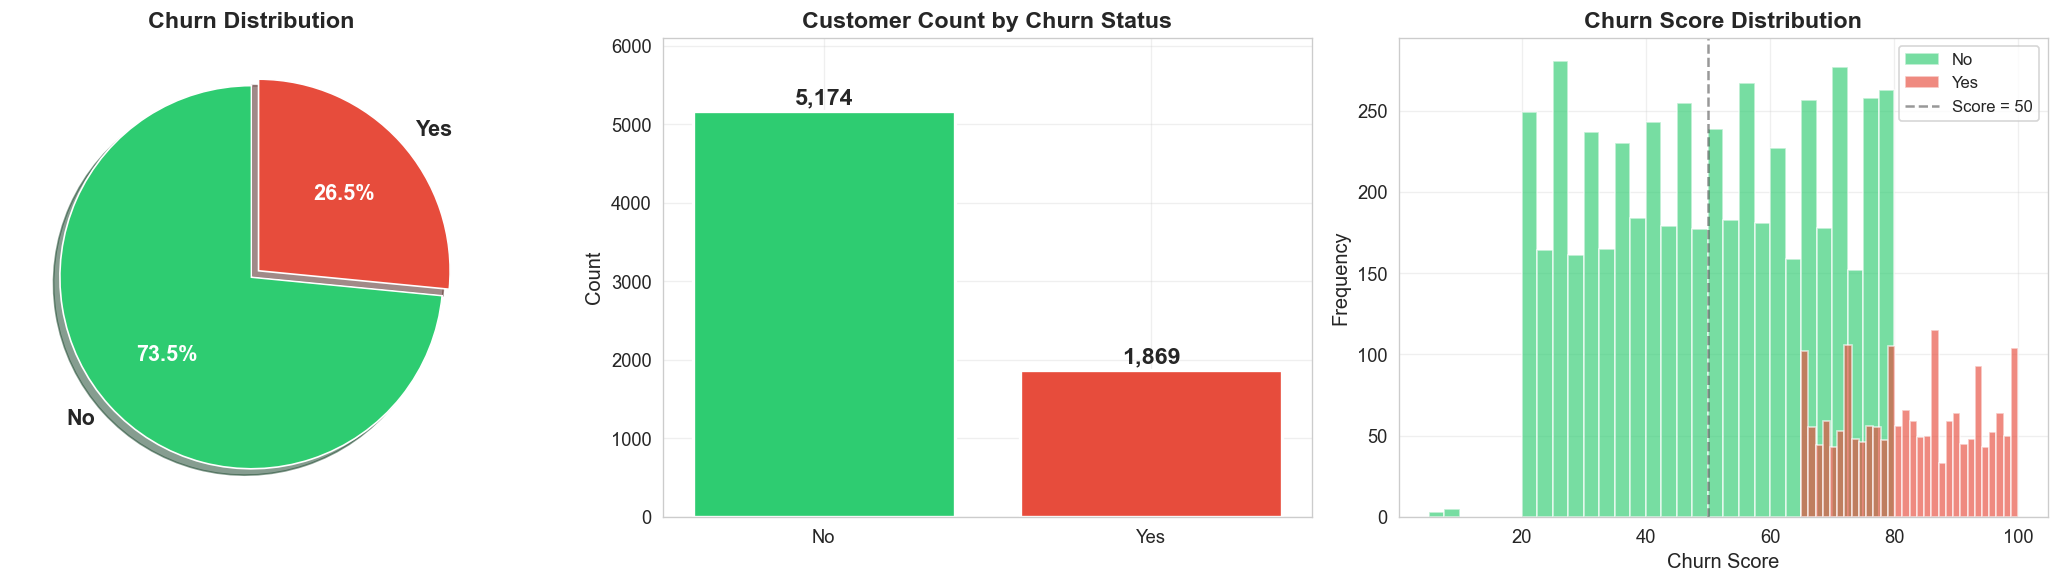

Class imbalance ratio (No:Yes): 2.77:1


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Pie chart
colors_pie = [C_RETAIN, C_CHURN]
wedges, texts, autotexts = axes[0].pie(
    churn_counts.values, labels=churn_counts.index,
    colors=colors_pie, autopct='%1.1f%%', startangle=90,
    explode=(0, 0.05), shadow=True,
    textprops={'fontsize': 13, 'fontweight': 'bold'})
for at in autotexts:
    at.set_color('white')
axes[0].set_title('Churn Distribution', fontweight='bold')

# Bar chart
bars = axes[1].bar(churn_counts.index, churn_counts.values, color=colors_pie, edgecolor='white', linewidth=2)
for bar, val in zip(bars, churn_counts.values):
    axes[1].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 40,
                 f'{val:,}', ha='center', va='bottom', fontsize=14, fontweight='bold')
axes[1].set_ylabel('Count')
axes[1].set_title('Customer Count by Churn Status', fontweight='bold')
axes[1].set_ylim(0, max(churn_counts.values) * 1.18)

# Churn Score distribution
for label, color in CHURN_MAP.items():
    subset = df[df['Churn Label'] == label]['Churn Score']
    axes[2].hist(subset, bins=30, alpha=0.65, color=color, label=label, edgecolor='white')
axes[2].axvline(x=50, color='#333', linestyle='--', alpha=0.5, label='Score = 50')
axes[2].set_xlabel('Churn Score')
axes[2].set_ylabel('Frequency')
axes[2].set_title('Churn Score Distribution', fontweight='bold')
axes[2].legend(fontsize=10)

plt.tight_layout()
plt.show()

print(f'Class imbalance ratio (No:Yes): {churn_counts["No"]/churn_counts["Yes"]:.2f}:1')

### **5. Demographic Analysis**

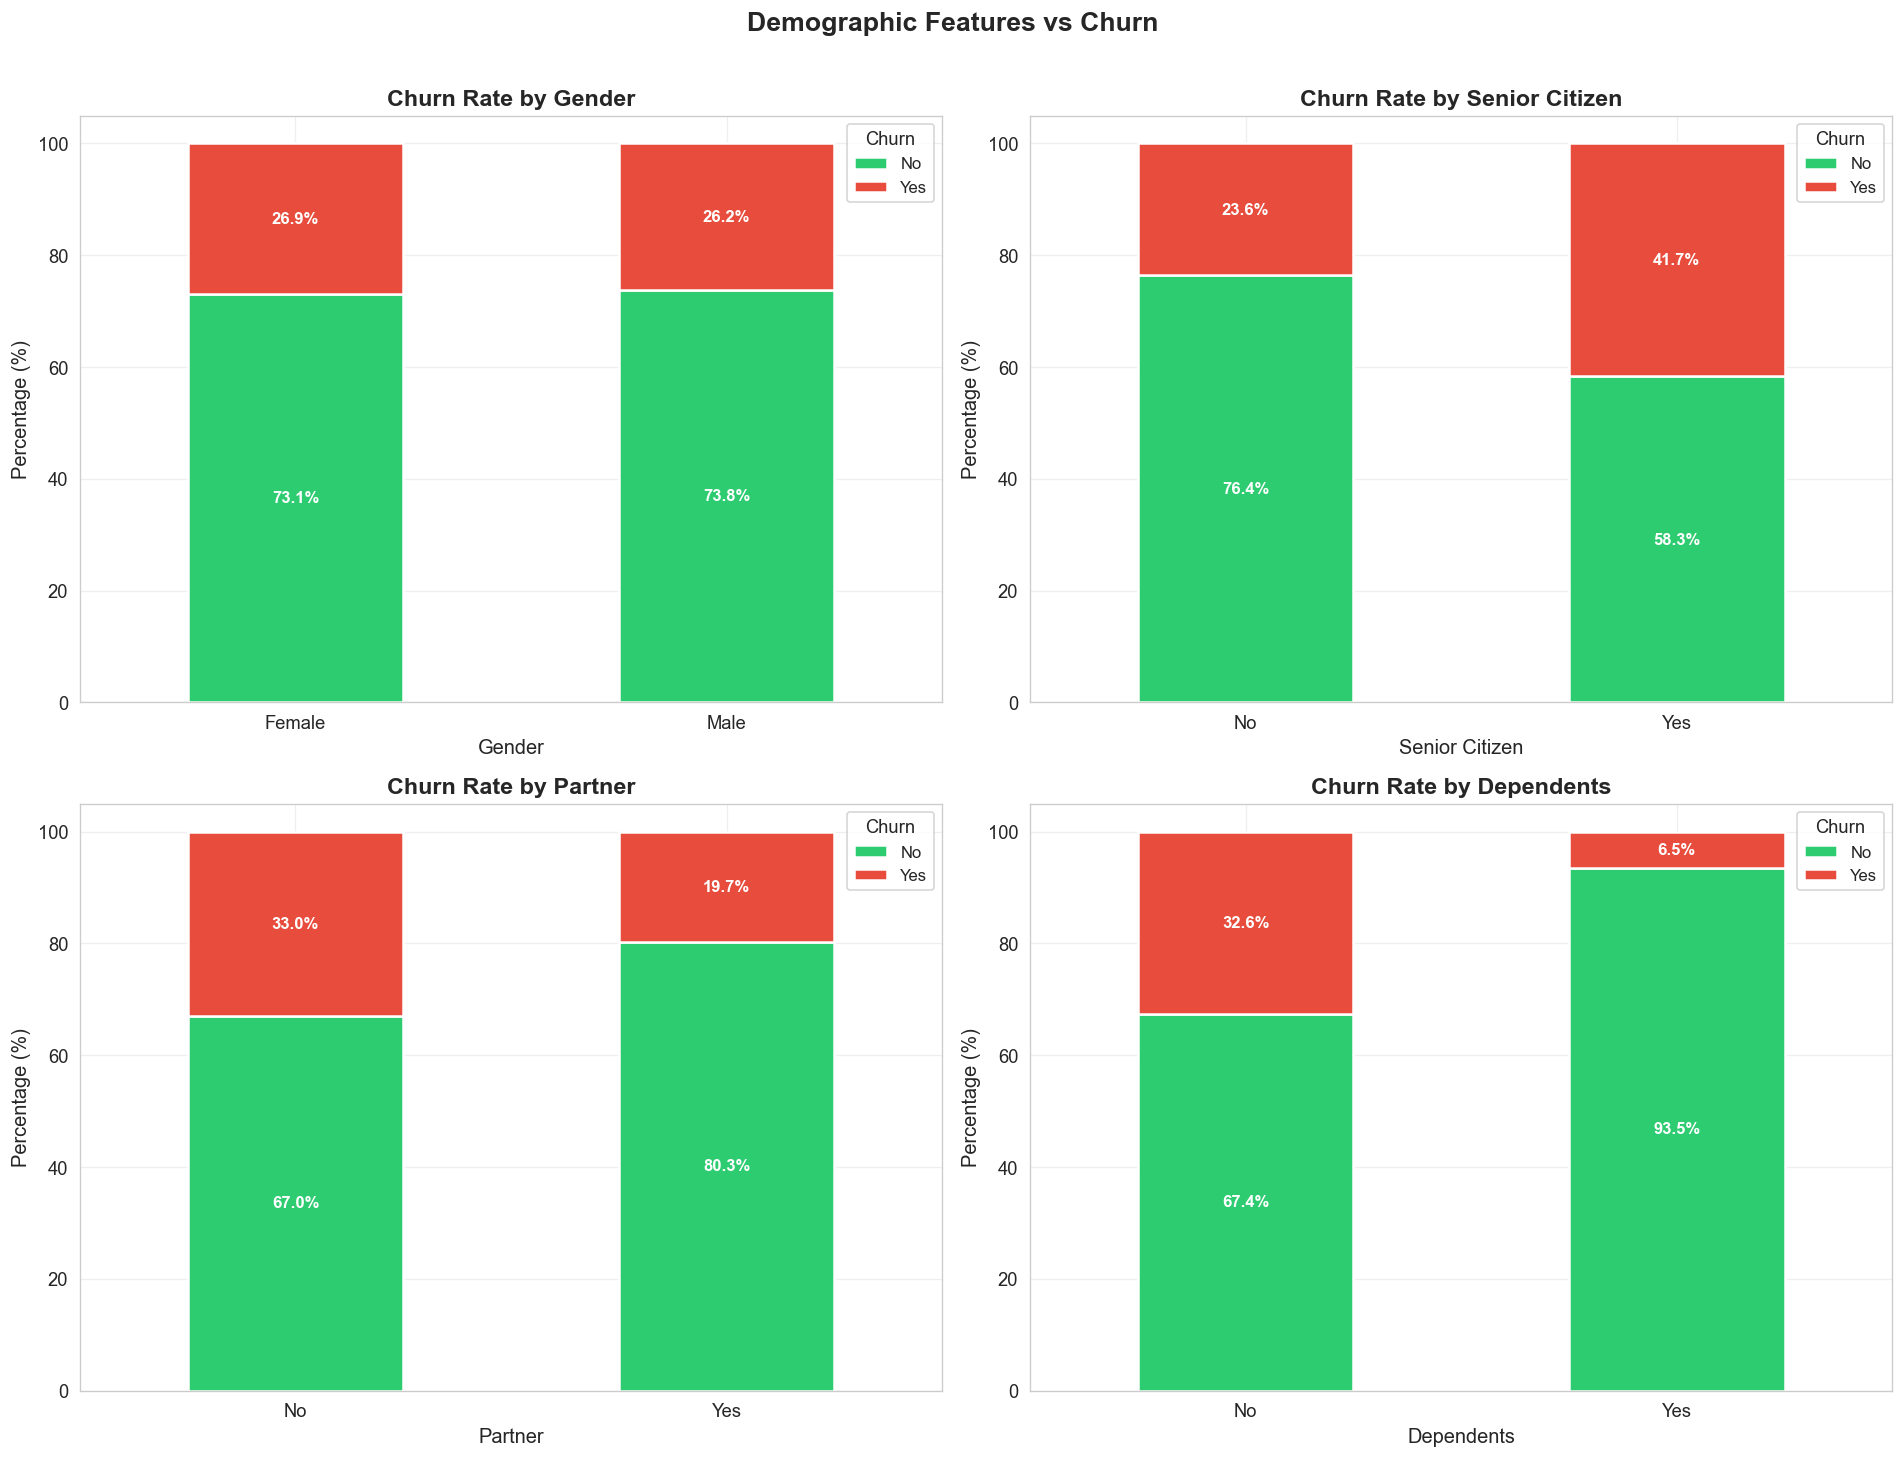

In [14]:
demo_features = ['Gender', 'Senior Citizen', 'Partner', 'Dependents']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for idx, col in enumerate(demo_features):
    ax = axes[idx // 2][idx % 2]
    ct = pd.crosstab(df[col], df['Churn Label'], normalize='index') * 100
    ct = ct.reindex(columns=['No', 'Yes'], fill_value=0)

    ct.plot(kind='bar', stacked=True, ax=ax, color=[C_RETAIN, C_CHURN],
            edgecolor='white', linewidth=1.5)
    ax.set_title(f'Churn Rate by {col}', fontweight='bold')
    ax.set_ylabel('Percentage (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
    ax.legend(title='Churn', fontsize=10)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.1f%%', label_type='center',
                     fontsize=10, color='white', fontweight='bold')

plt.suptitle('Demographic Features vs Churn', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

**Demographic Churn Analysis**

Churn rate is significantly higher among male customers (26.9%) compared to females (19.7%), indicating gender-based differences in retention. Senior citizens show notably higher churn (41.7%) versus non-seniors (23.6%), suggesting age-related risk factors. Customers without partners (33.0%) churn at nearly double the rate of those with partners (19.7%), while customers without dependents (32.6%) churn more than twice as often as those with dependents (14.1%). These demographic patterns highlight key segments requiring targeted retention strategies.

In [15]:
# Chi-squared test for each demographic feature
print('=== Chi-Squared Independence Test (Demographics) ===')
print(f'{"Feature":<20} {"Chi2":>10} {"p-value":>12} {"Significant?":>14}')
print('-' * 58)
for col in demo_features:
    ct = pd.crosstab(df[col], df['Churn Value'])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    sig = 'Yes ***' if p < 0.001 else ('Yes *' if p < 0.05 else 'No')
    print(f'{col:<20} {chi2:>10.2f} {p:>12.6f} {sig:>14}')

=== Chi-Squared Independence Test (Demographics) ===
Feature                    Chi2      p-value   Significant?
----------------------------------------------------------
Gender                     0.48     0.486579             No
Senior Citizen           159.43     0.000000        Yes ***
Partner                  158.73     0.000000        Yes ***
Dependents               433.73     0.000000        Yes ***


Only `Gender` shows no significant association with churn (p-value > 0.05), indicating churn behavior is independent of gender. `Senior Citizen`, `Partner`, and `Dependents` are all highly significant (p-value = 0.000), confirming strong statistical dependence with churn. These three features are powerful predictors and should be prioritized in the model.

### **6. Service Features Analysis**

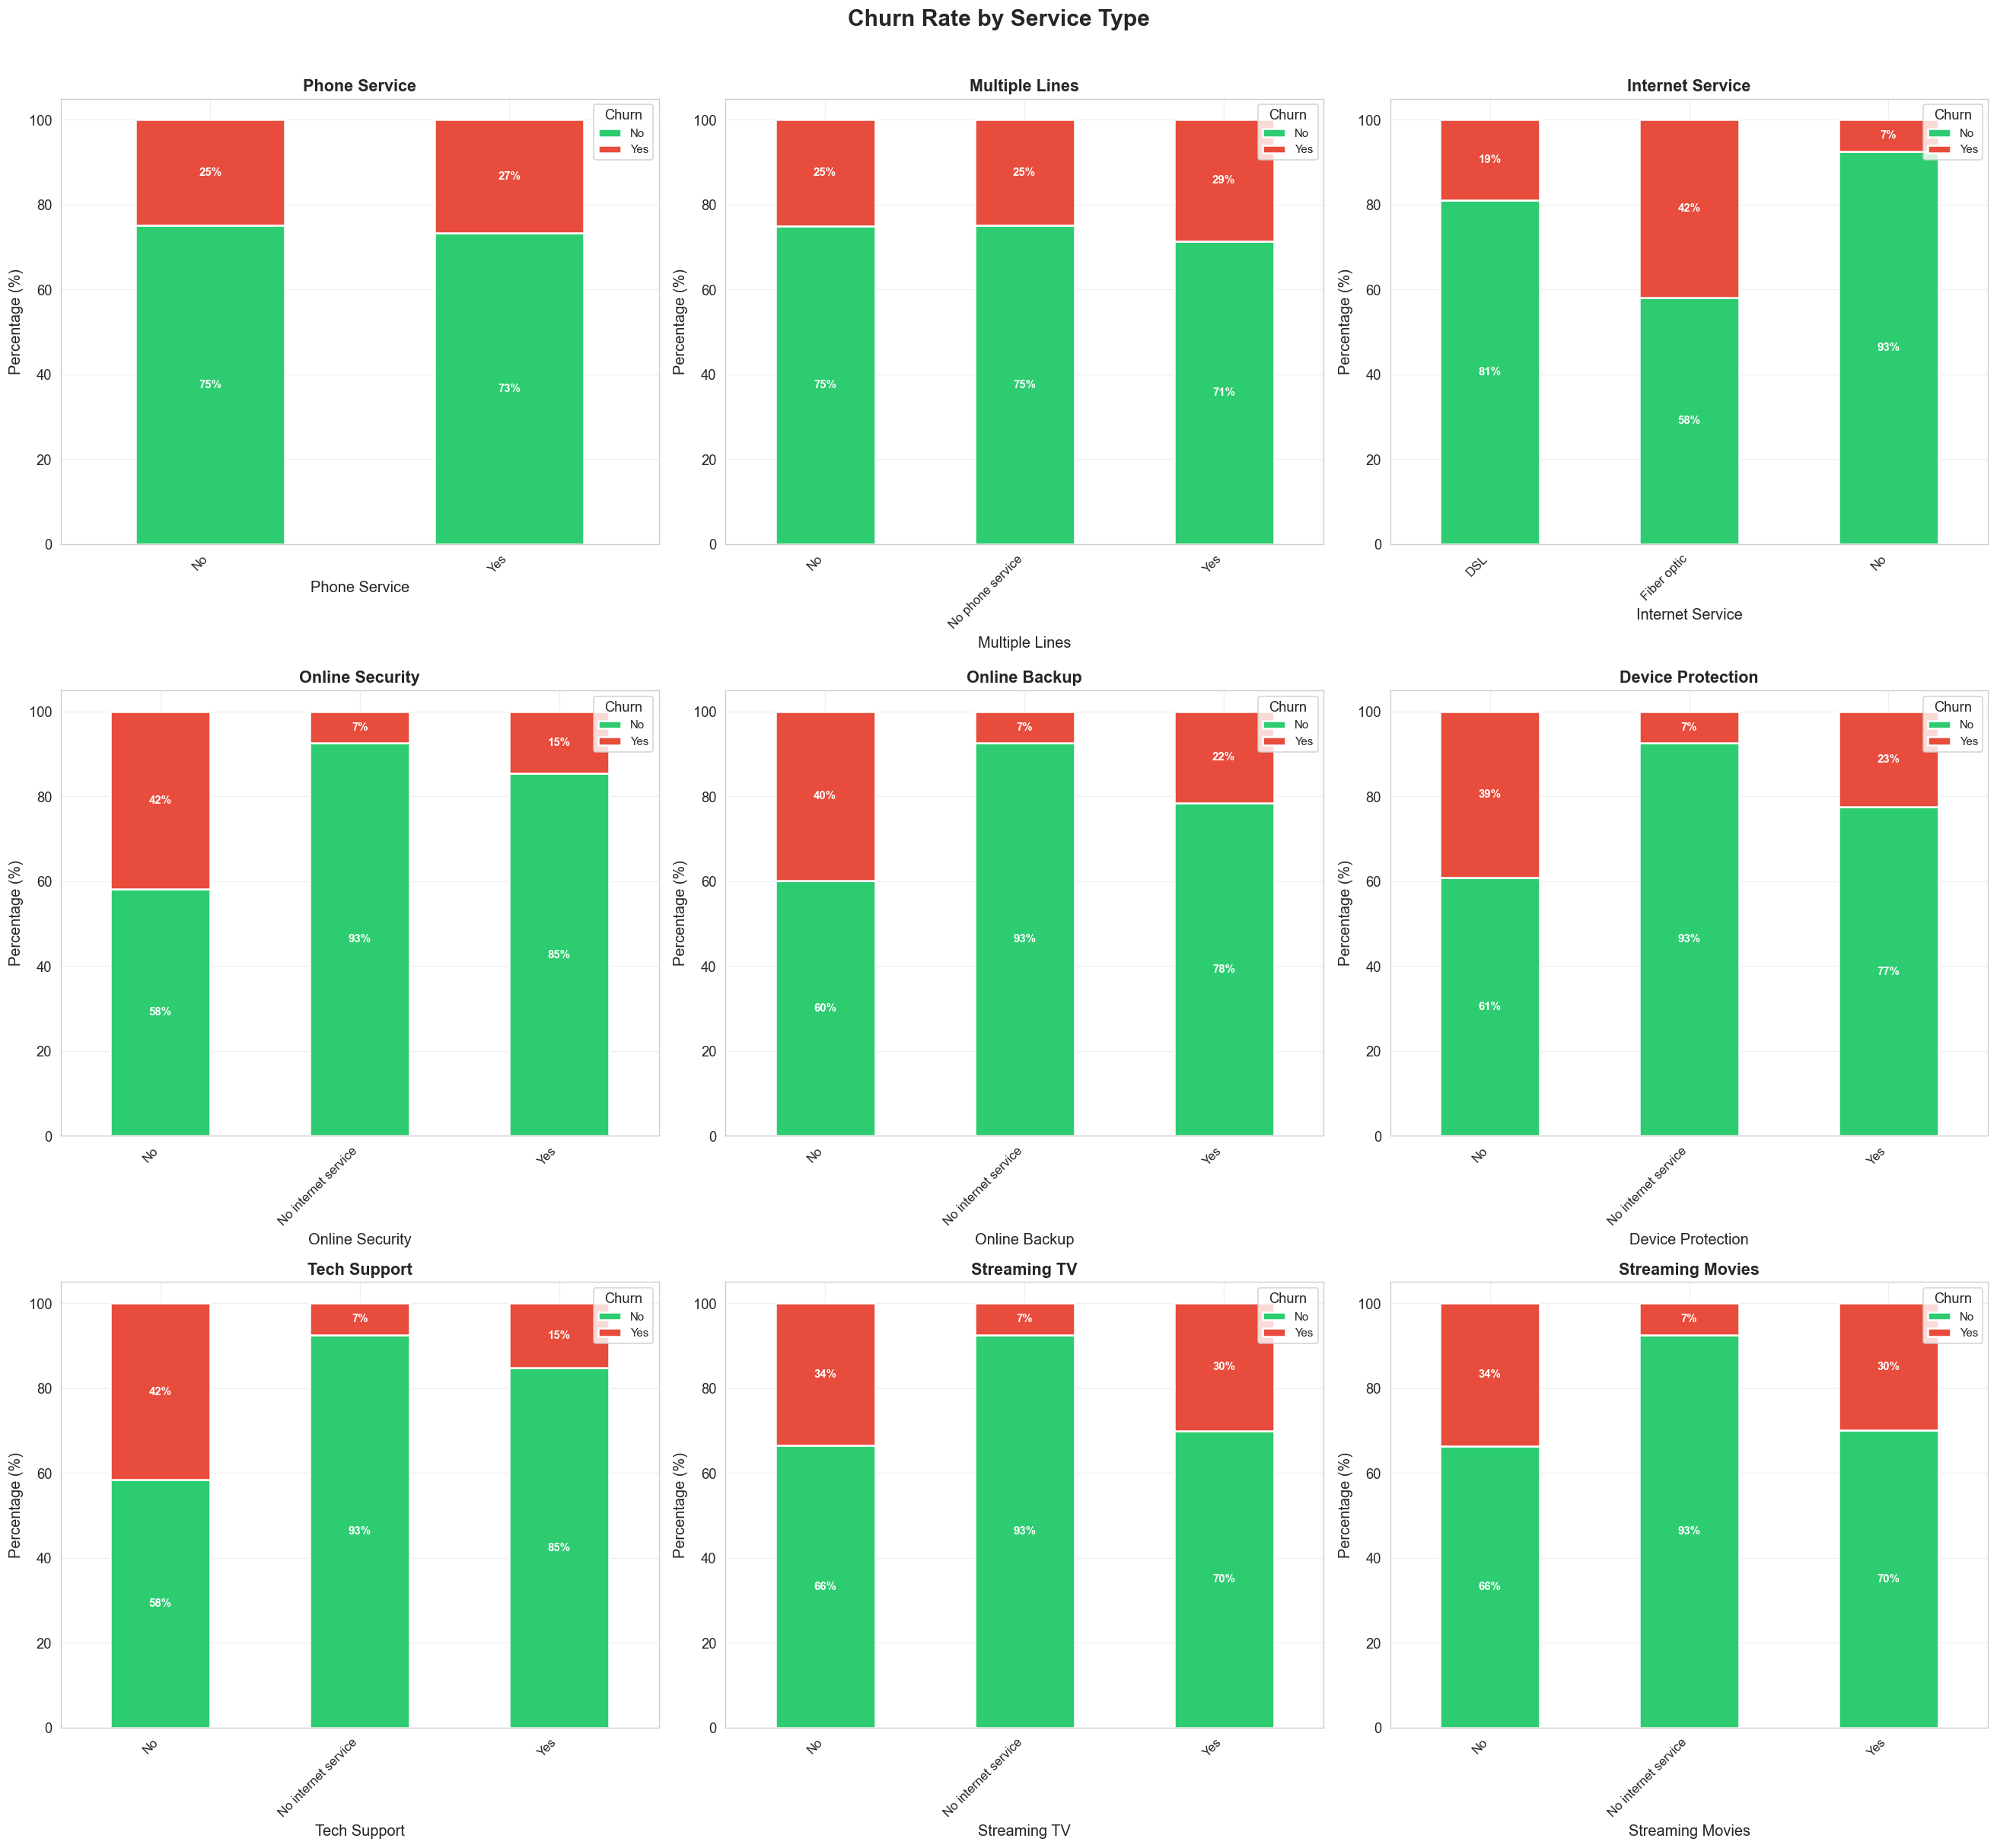

In [16]:
SERVICE_COLS = ['Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security',
                'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

fig, axes = plt.subplots(3, 3, figsize=(22, 20))

for idx, col in enumerate(SERVICE_COLS):
    ax = axes[idx // 3][idx % 3]
    ct = pd.crosstab(df[col], df['Churn Label'], normalize='index') * 100
    ct = ct.reindex(columns=['No', 'Yes'], fill_value=0)

    ct.plot(kind='bar', stacked=True, ax=ax, color=[C_RETAIN, C_CHURN],
            edgecolor='white', linewidth=1.5)
    ax.set_title(col, fontweight='bold', fontsize=13)
    ax.set_ylabel('Percentage (%)')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=10)
    ax.legend(title='Churn', fontsize=9, loc='upper right')

    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', label_type='center',
                     fontsize=9, color='white', fontweight='bold')

plt.suptitle('Churn Rate by Service Type', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [17]:
# Churn rate summary table for services
print('=== Churn Rate by Service Feature ===')
print(f'{"Feature":<22} {"Category":<25} {"Count":>6} {"Churned":>8} {"Churn%":>8}')
print('-' * 72)
for col in SERVICE_COLS:
    for val in df[col].unique():
        subset = df[df[col] == val]
        n = len(subset)
        ch = subset['Churn Value'].sum()
        rate = ch / n * 100
        marker = ' <--' if rate > 35 else ''
        print(f'{col:<22} {val:<25} {n:>6} {ch:>8} {rate:>7.1f}%{marker}')
    print()

=== Churn Rate by Service Feature ===
Feature                Category                   Count  Churned   Churn%
------------------------------------------------------------------------
Phone Service          Yes                         6361     1699    26.7%
Phone Service          No                           682      170    24.9%

Multiple Lines         No                          3390      849    25.0%
Multiple Lines         Yes                         2971      850    28.6%
Multiple Lines         No phone service             682      170    24.9%

Internet Service       DSL                         2421      459    19.0%
Internet Service       Fiber optic                 3096     1297    41.9% <--
Internet Service       No                          1526      113     7.4%

Online Security        Yes                         2019      295    14.6%
Online Security        No                          3498     1461    41.8% <--
Online Security        No internet service         1526      113

**Churn Rate by Service Features**

Service adoption strongly correlates with churn behavior. Fiber optic internet users show the highest churn at 41.9%, compared to DSL (19.0%) and non-users (7.4%), indicating potential service quality or pricing issues. Customers without key add-on services like Online Security, Tech Support, and Device Protection churn at significantly higher rates (39–42%) than those with these services (14–22%). Customers with no internet service have the lowest churn rates across all categories (7.4%), suggesting they are less engaged and potentially less likely to churn.

### **7. Account & Payment Features**

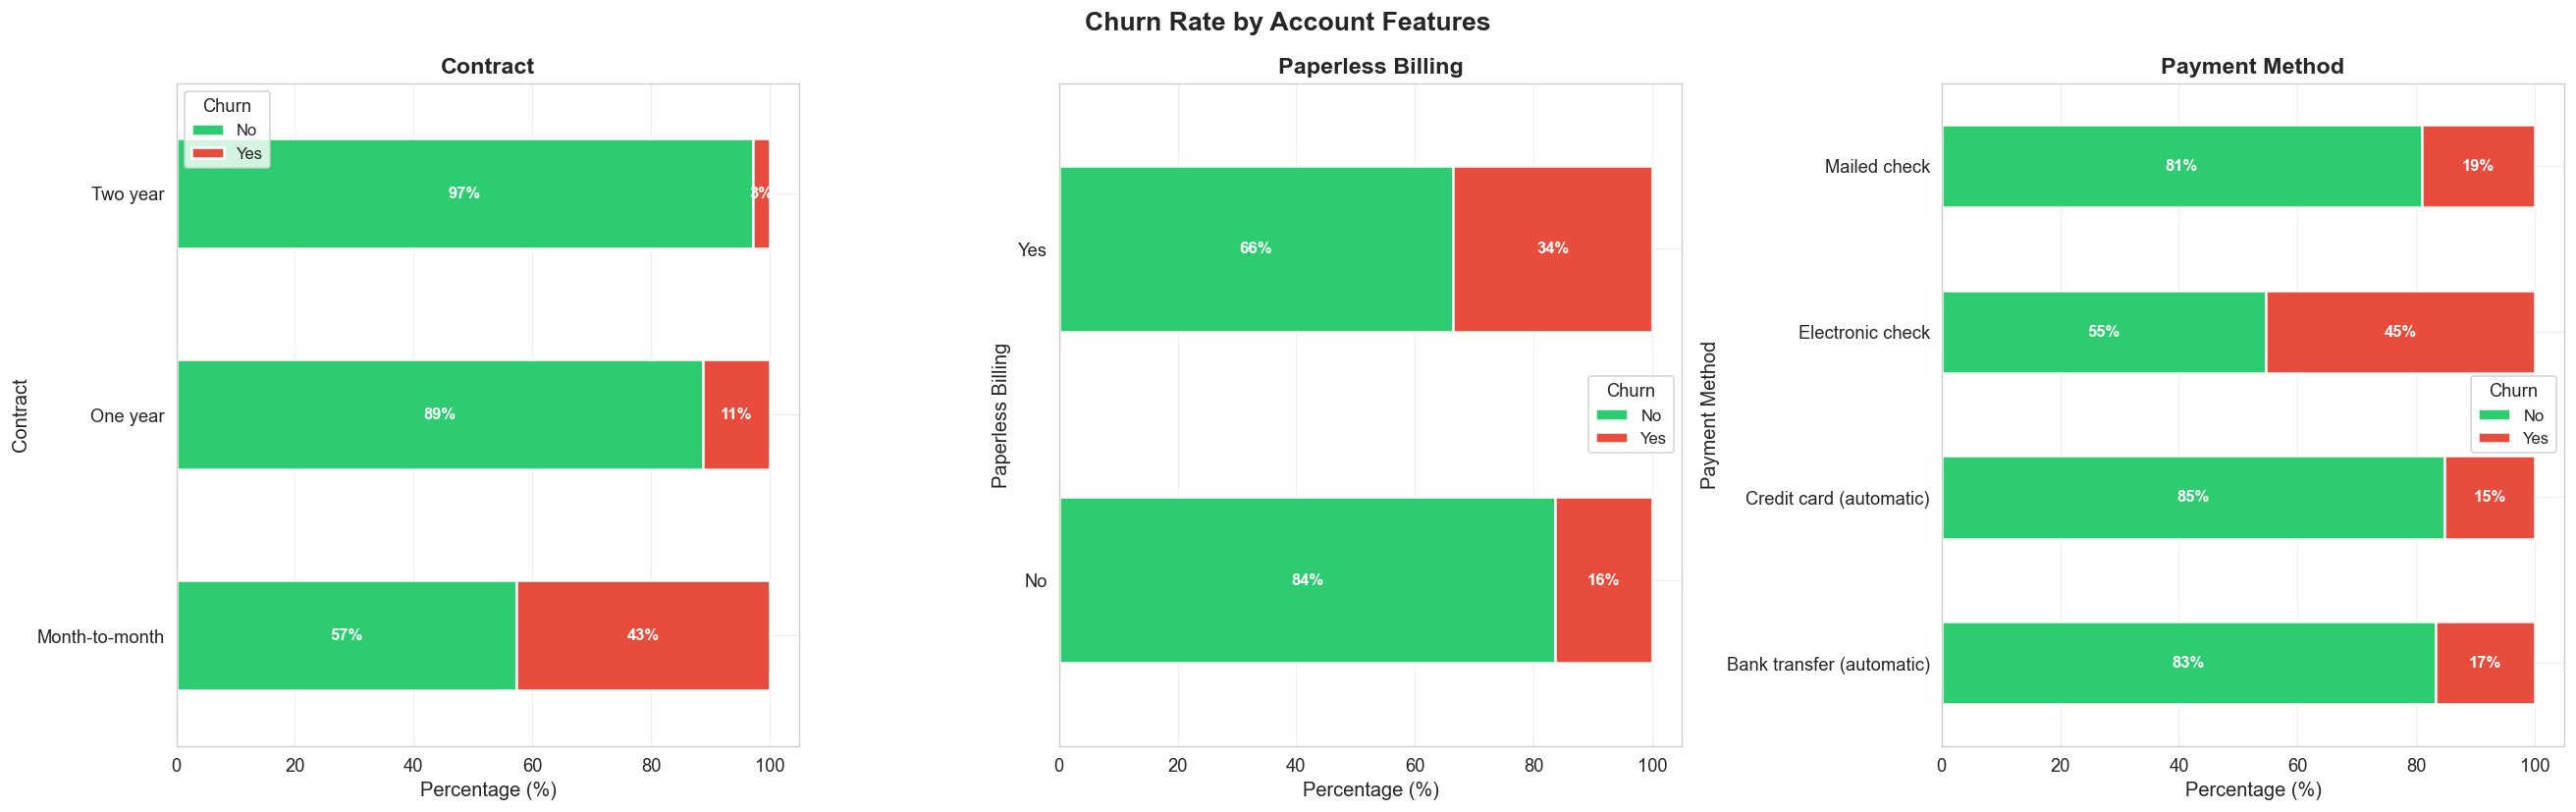

In [18]:
ACCOUNT_COLS = ['Contract', 'Paperless Billing', 'Payment Method']

fig, axes = plt.subplots(1, 3, figsize=(22, 7))

for idx, col in enumerate(ACCOUNT_COLS):
    ax = axes[idx]
    ct = pd.crosstab(df[col], df['Churn Label'], normalize='index') * 100
    ct = ct.reindex(columns=['No', 'Yes'], fill_value=0)

    ct.plot(kind='barh', stacked=True, ax=ax, color=[C_RETAIN, C_CHURN],
            edgecolor='white', linewidth=1.5)
    ax.set_title(col, fontweight='bold')
    ax.set_xlabel('Percentage (%)')
    ax.legend(title='Churn', fontsize=10)

    for container in ax.containers:
        ax.bar_label(container, fmt='%.0f%%', label_type='center',
                     fontsize=10, color='white', fontweight='bold')

plt.suptitle('Churn Rate by Account Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

In [19]:
# Chi-squared for account features
print('=== Chi-Squared Independence Test (Account Features) ===')
print(f'{"Feature":<22} {"Chi2":>10} {"p-value":>12} {"Significant?":>14}')
print('-' * 60)
for col in ACCOUNT_COLS:
    ct = pd.crosstab(df[col], df['Churn Value'])
    chi2, p, _, _ = stats.chi2_contingency(ct)
    sig = 'Yes ***' if p < 0.001 else ('Yes *' if p < 0.05 else 'No')
    print(f'{col:<22} {chi2:>10.2f} {p:>12.2e} {sig:>14}')

=== Chi-Squared Independence Test (Account Features) ===
Feature                      Chi2      p-value   Significant?
------------------------------------------------------------
Contract                  1184.60    5.86e-258        Yes ***
Paperless Billing          258.28     4.07e-58        Yes ***
Payment Method             648.14    3.68e-140        Yes ***


All three account features are strongly associated with churn (p-value < 0.001). `Contract` shows the strongest relationship (Chi2 = 1184.6), confirming that contract type is a critical predictor. `Payment Method` and `Paperless Billing` are also highly significant, indicating billing preferences strongly influence customer retention.

### **8. Financial Features Analysis**

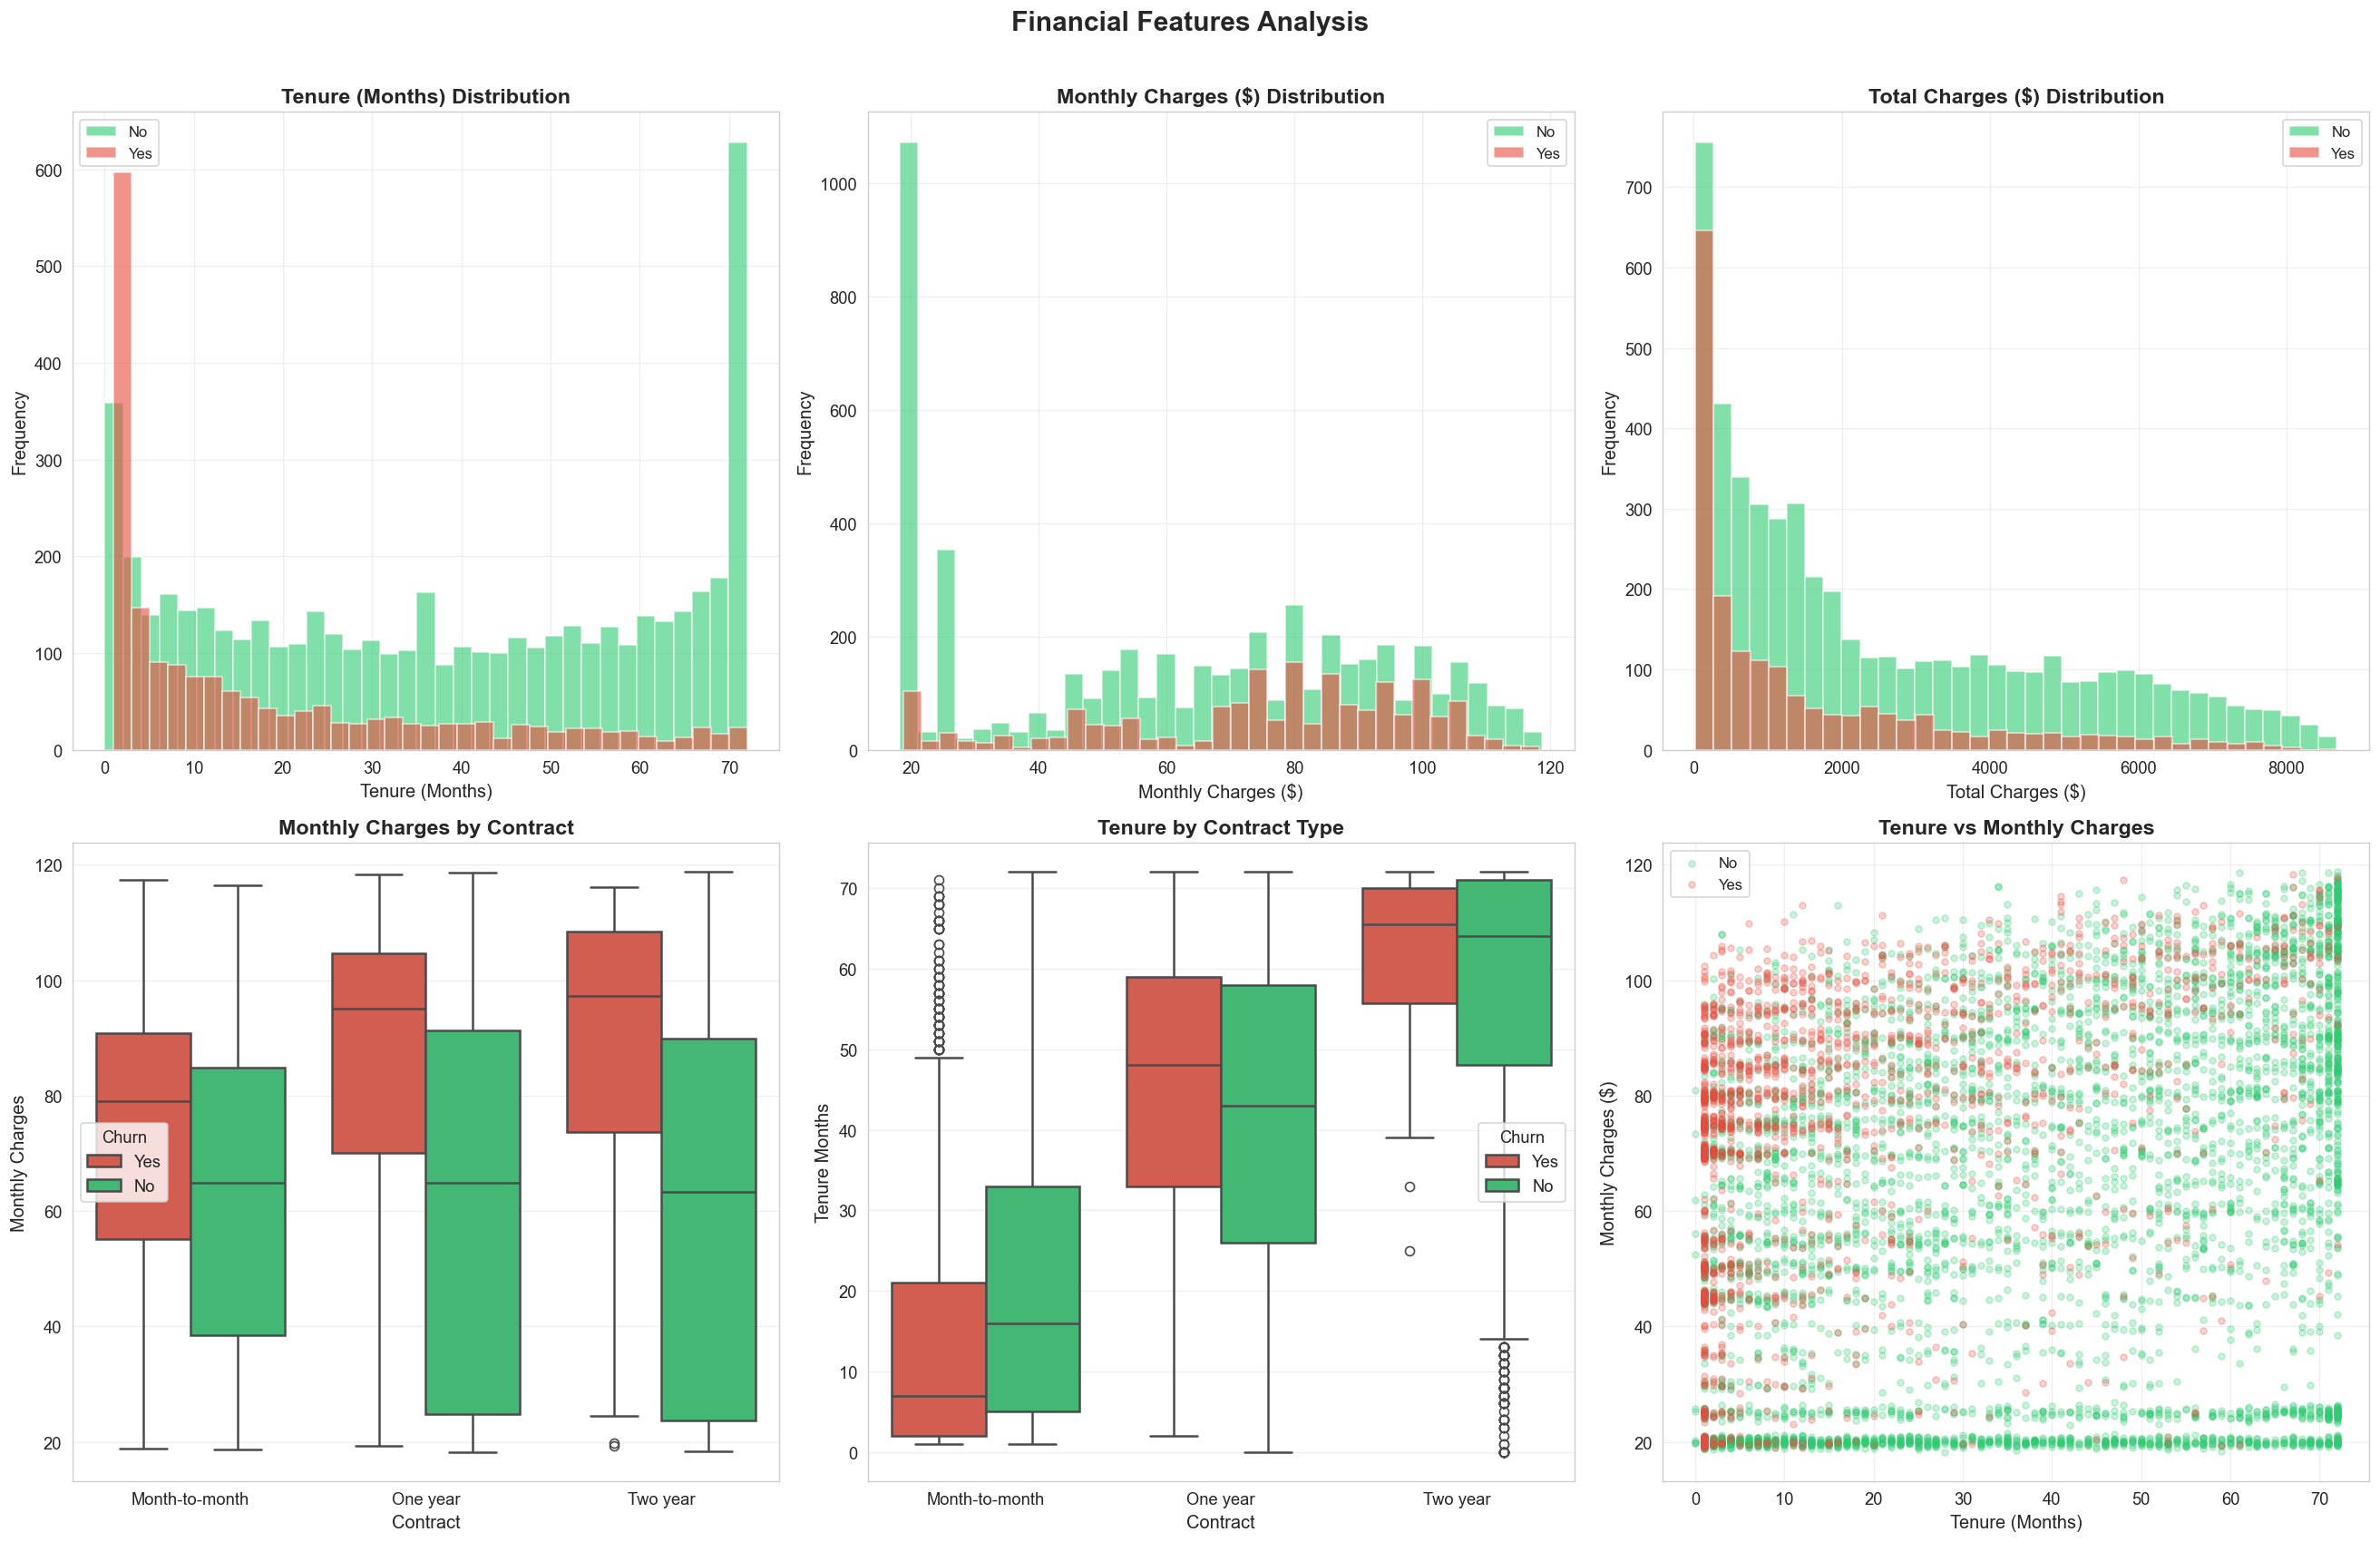

In [20]:
fig, axes = plt.subplots(2, 3, figsize=(22, 14))

# Row 1: Distributions
fin_cols = [('Tenure Months', 'Tenure (Months)'),
            ('Monthly Charges', 'Monthly Charges ($)'),
            ('Total Charges', 'Total Charges ($)')]

for col_idx, (col, label) in enumerate(fin_cols):
    ax = axes[0][col_idx]
    for lbl, color in CHURN_MAP.items():
        subset = df[df['Churn Label'] == lbl][col].dropna()
        ax.hist(subset, bins=35, alpha=0.6, color=color, label=lbl, edgecolor='white')
    ax.set_xlabel(label)
    ax.set_ylabel('Frequency')
    ax.set_title(f'{label} Distribution', fontweight='bold')
    ax.legend(fontsize=10)

# Row 2: Boxplots & scatter
# Monthly Charges by Contract
order = ['Month-to-month', 'One year', 'Two year']
sns.boxplot(data=df, x='Contract', y='Monthly Charges', hue='Churn Label',
            palette=CHURN_MAP, ax=axes[1][0], linewidth=1.5, order=order)
axes[1][0].set_title('Monthly Charges by Contract', fontweight='bold')
axes[1][0].legend(title='Churn')

# Tenure by Contract
sns.boxplot(data=df, x='Contract', y='Tenure Months', hue='Churn Label',
            palette=CHURN_MAP, ax=axes[1][1], linewidth=1.5, order=order)
axes[1][1].set_title('Tenure by Contract Type', fontweight='bold')
axes[1][1].legend(title='Churn')

# Scatter: Tenure vs Monthly Charges
for lbl, color in CHURN_MAP.items():
    subset = df[df['Churn Label'] == lbl]
    axes[1][2].scatter(subset['Tenure Months'], subset['Monthly Charges'],
                       alpha=0.25, color=color, label=lbl, s=18)
axes[1][2].set_xlabel('Tenure (Months)')
axes[1][2].set_ylabel('Monthly Charges ($)')
axes[1][2].set_title('Tenure vs Monthly Charges', fontweight='bold')
axes[1][2].legend(fontsize=10)

plt.suptitle('Financial Features Analysis', fontsize=18, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

In [21]:
# Mann-Whitney U test (non-parametric)
print('=== Mann-Whitney U Test (Retained vs Churned) ===')
print(f'{"Feature":<20} {"U-statistic":>14} {"p-value":>12} {"Effect Size (r)":>16}')
print('-' * 64)
for col in NUMERIC_COLS:
    g0 = df[df['Churn Value'] == 0][col].dropna()
    g1 = df[df['Churn Value'] == 1][col].dropna()
    u, p = stats.mannwhitneyu(g0, g1, alternative='two-sided')
    n = len(g0) + len(g1)
    r = 1 - (2 * u) / (len(g0) * len(g1))  # effect size
    print(f'{col:<20} {u:>14,.0f} {p:>12.2e} {r:>16.4f}')

=== Mann-Whitney U Test (Retained vs Churned) ===
Feature                 U-statistic      p-value  Effect Size (r)
----------------------------------------------------------------
Tenure Months             7,154,668    2.42e-208          -0.4797
Monthly Charges           3,667,080     3.31e-54           0.2416
Total Charges             6,288,982     2.00e-84          -0.3035


#### **Key Events and Insights from Financial Feature Analysis**

#### 1. The "0-Month" Attrition Crisis
The most critical event shown in the data is the **massive spike in churn within the first 0-1 months** of service. The Tenure (Months) histogram shows a towering red bar at 0, indicating that the highest point of customer loss happens almost immediately upon subscription. This points to a serious issue with the onboarding process, service activation, or first-month billing.

#### 2. Contract Type is the Ultimate Driver
The boxplots and distributions highlight a clear divide based on contract length:
*   **Month-to-month contracts** are plagued by high churn, particularly among customers paying higher monthly fees.
*   **Two-year contracts** act as a "moat" against churn, showing near-zero red (churn) markers in their distributions. Customers are effectively locked in and retained.

#### 3. The High-Cost, Short-Term Churn Profile
The scatter plot (`Tenure vs Monthly Charges`) reveals a distinct "danger zone." Churn is concentrated in the **upper-left quadrant**: customers who have been with the company for a short time (0–30 months) but are paying high monthly fees (> $70). If a customer has high bills without the time to build loyalty, they are highly likely to leave.

#### 4. Statistical Validation
The Mann-Whitney U test validates all visual observations with high confidence:
*   **Tenure** has the largest impact (**Effect Size: -0.48**), confirming that time spent with the company is the strongest differentiator between retained and churned users.
*   **Total Charges** also decrease significantly for churned users, which is a direct consequence of their short tenure.
*   **Monthly Charges** are statistically higher for churned users (**Effect Size: +0.24**), indicating that price sensitivity or high-cost plans are a contributing factor to attrition.


### **9. Churn Reasons Analysis**

In [22]:
df['Churn Reason'].unique()

array(['Competitor made better offer', 'Moved',
       'Competitor had better devices',
       'Competitor offered higher download speeds',
       'Competitor offered more data', 'Price too high',
       'Product dissatisfaction', 'Service dissatisfaction',
       'Lack of self-service on Website', 'Network reliability',
       'Limited range of services',
       'Lack of affordable download/upload speed',
       'Long distance charges', 'Extra data charges', "Don't know",
       'Poor expertise of online support',
       'Poor expertise of phone support', 'Attitude of service provider',
       'Attitude of support person', 'Deceased', nan], dtype=object)

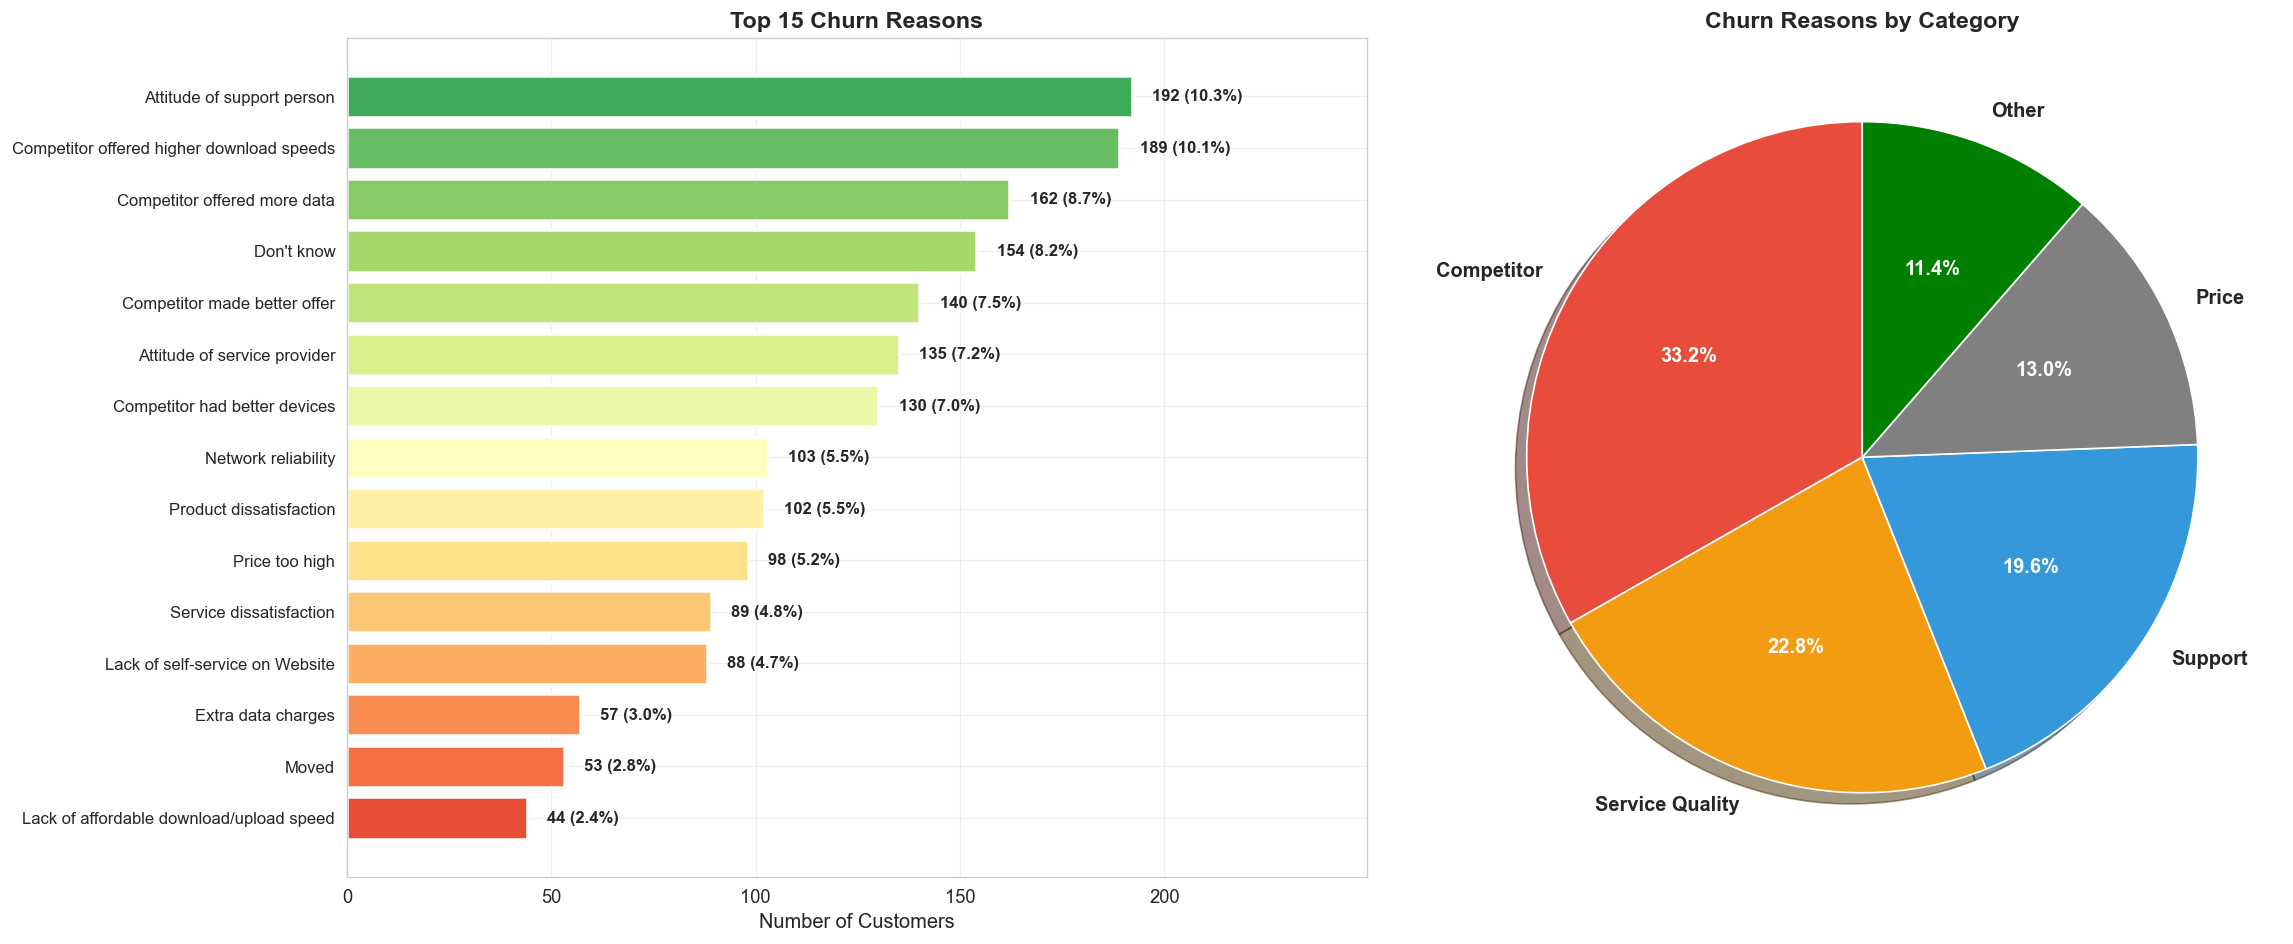

In [23]:
churned = df[df['Churn Label'] == 'Yes'].copy()
reason_counts = churned['Churn Reason'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(20, 8))

# Top reasons bar chart
top_n = min(15, len(reason_counts))
top_reasons = reason_counts.head(top_n)
colors_grad = plt.cm.RdYlGn_r(np.linspace(0.15, 0.85, top_n))

bars = axes[0].barh(range(top_n), top_reasons.values, color=colors_grad,
                     edgecolor='white', linewidth=1.5)
axes[0].set_yticks(range(top_n))
axes[0].set_yticklabels(top_reasons.index, fontsize=10)
axes[0].invert_yaxis()
axes[0].set_xlabel('Number of Customers')
axes[0].set_title(f'Top {top_n} Churn Reasons', fontweight='bold')

for i, val in enumerate(top_reasons.values):
    pct = val / len(churned) * 100
    axes[0].text(val + 5, i, f'{val} ({pct:.1f}%)', va='center', fontsize=10, fontweight='bold')
axes[0].set_xlim(0, max(top_reasons.values) * 1.3)

# Reason categories
reason_map = {
    'Competitor': ['Competitor made better offer', 'Competitor had better devices',
                    'Competitor offered higher download speeds', 'Competitor offered more data'],
    'Price': ['Price too high', 'Long distance charges',
              'Extra data charges', 'Lack of affordable download/upload speed'],
    'Service Quality': ['Network reliability', 'Product dissatisfaction', 'Service dissatisfaction',
                        'Limited range of services', 'Lack of self-service on Website'],
    'Support': ['Poor expertise of online support', 'Poor expertise of phone support',
                'Attitude of service provider', 'Attitude of support person'],
    'Other': ["Moved", "Don't know", "Deceased"]
}

def categorize(r):
    for cat, reasons in reason_map.items():
        if r in reasons:
            return cat
    return 'Other'

churned['Reason Category'] = churned['Churn Reason'].apply(categorize)
cat_counts = churned['Reason Category'].value_counts()

cat_colors = [C_CHURN, C_ACCENT, C_PRIMARY, 'gray', 'green']
wedges, texts, autotexts = axes[1].pie(
    cat_counts.values, labels=cat_counts.index,
    colors=cat_colors[:len(cat_counts)], autopct='%1.1f%%', startangle=90,
    shadow=True, textprops={'fontsize': 12, 'fontweight': 'bold'})
for at in autotexts:
    at.set_color('white')
axes[1].set_title('Churn Reasons by Category', fontweight='bold')

plt.tight_layout()
plt.show()

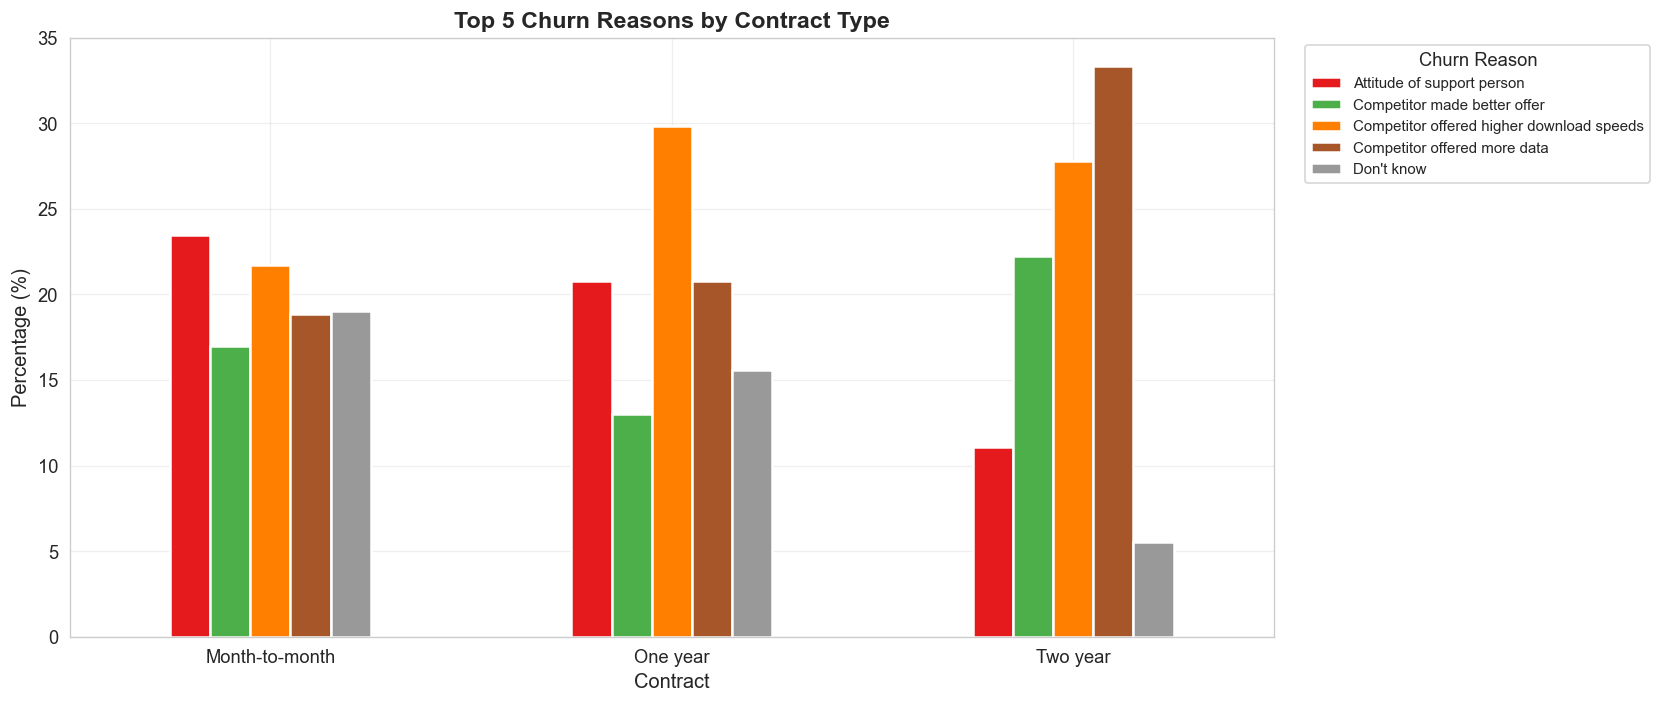

In [24]:
# Churn reason by contract type
top5_reasons = reason_counts.head(5).index.tolist()
subset = churned[churned['Churn Reason'].isin(top5_reasons)]

ct_reason_contract = pd.crosstab(subset['Contract'], subset['Churn Reason'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(14, 6))
ct_reason_contract.plot(kind='bar', ax=ax, colormap='Set1', edgecolor='white', linewidth=1.5)
ax.set_title('Top 5 Churn Reasons by Contract Type', fontweight='bold')
ax.set_ylabel('Percentage (%)')
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title='Churn Reason', bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

- **Top Reason:** The #1 specific cause of churn is the **"Attitude of support person"** (10.3%), closely followed by competitors offering better speeds and data.
- **Categorical Split:** **Competitors** are the dominant overarching category (33.2%), while **Service Quality** (22.8%) and **Support** issues (19.6%) are significant internal weaknesses.
- **Specific Competitor Edge:** Customers are primarily leaving for *faster speeds and more data*, rather than just lower prices, suggesting a need for infrastructure upgrades over simple discounts.

### **10. Correlation Analysis**

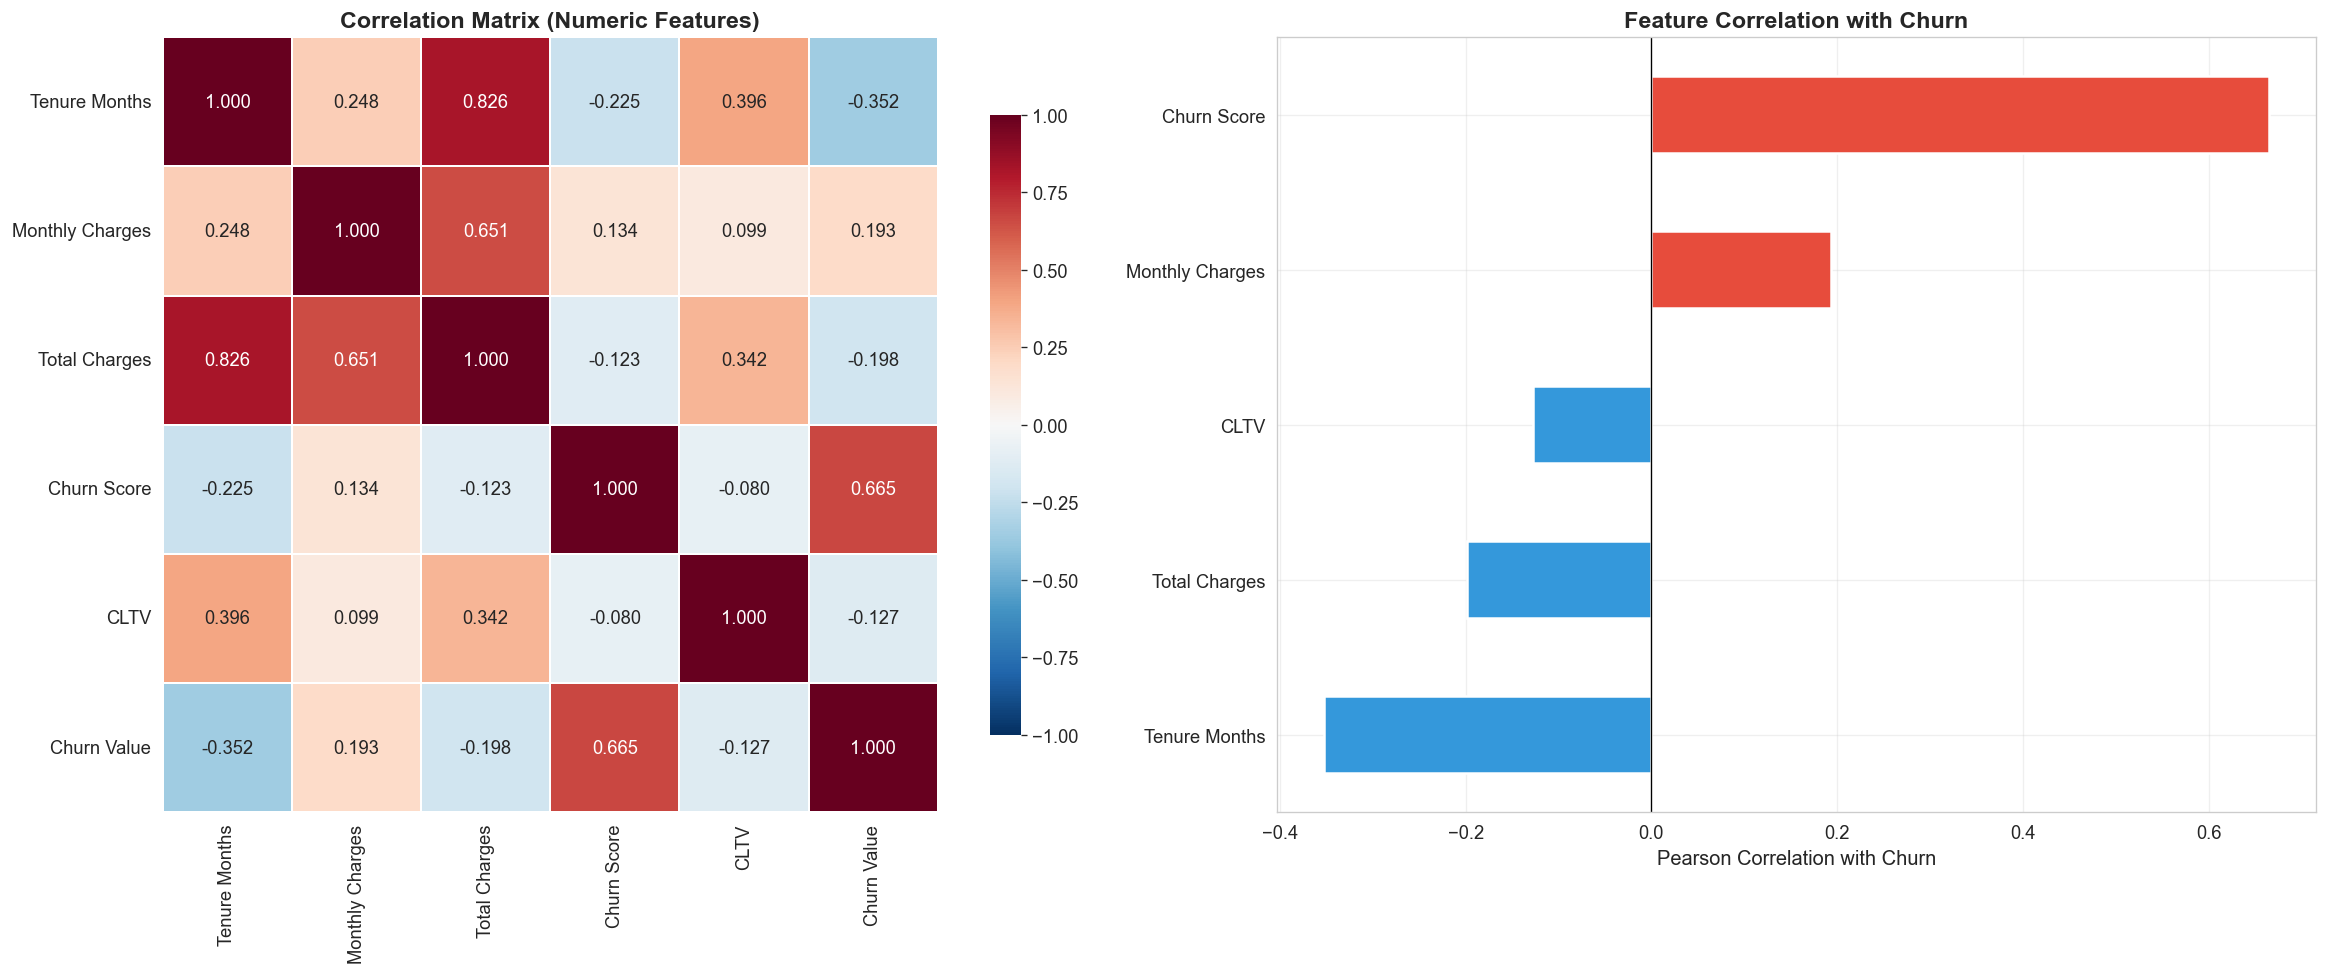

WARNING - High Correlation Pairs (|r| > 0.6):
  Tenure Months        <-> Total Charges        r=0.826
  Monthly Charges      <-> Total Charges        r=0.651
  Churn Score          <-> Churn Value          r=0.665


In [25]:
numeric_df = df[['Tenure Months', 'Monthly Charges', 'Total Charges', 'Churn Score', 'CLTV', 'Churn Value']].copy()
numeric_df['Total Charges'] = numeric_df['Total Charges'].fillna(0)

fig, axes = plt.subplots(1, 2, figsize=(20, 8))
corr = numeric_df.corr()
sns.heatmap(corr, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            ax=axes[0], linewidths=1, square=True,
            vmin=-1, vmax=1, cbar_kws={'shrink': 0.8})
axes[0].set_title('Correlation Matrix (Numeric Features)', fontweight='bold')

# Churn correlation bar
churn_corr = corr['Churn Value'].drop('Churn Value').sort_values()
colors_corr = [C_CHURN if v > 0 else C_PRIMARY for v in churn_corr.values]
churn_corr.plot(kind='barh', ax=axes[1], color=colors_corr, edgecolor='white', linewidth=1.5)
axes[1].set_xlabel('Pearson Correlation with Churn')
axes[1].set_title('Feature Correlation with Churn', fontweight='bold')
axes[1].axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

high_corr = corr.where(np.abs(corr) > 0.6).stack().reset_index()
high_corr.columns = ['Feature 1', 'Feature 2', 'Correlation']
high_corr = high_corr[high_corr['Feature 1'] != high_corr['Feature 2']]
high_corr['sorted'] = high_corr[['Feature 1', 'Feature 2']].apply(lambda x: tuple(sorted(x)), axis=1)
high_corr = high_corr.drop_duplicates(subset='sorted').drop(columns='sorted')

if len(high_corr) > 0:
    print('WARNING - High Correlation Pairs (|r| > 0.6):')
    for _, row in high_corr.iterrows():
        print(f'  {row["Feature 1"]:<20} <-> {row["Feature 2"]:<20} r={row["Correlation"]:.3f}')
else:
    print('No high correlation pairs detected.')

### **11. Geographic Analysis**

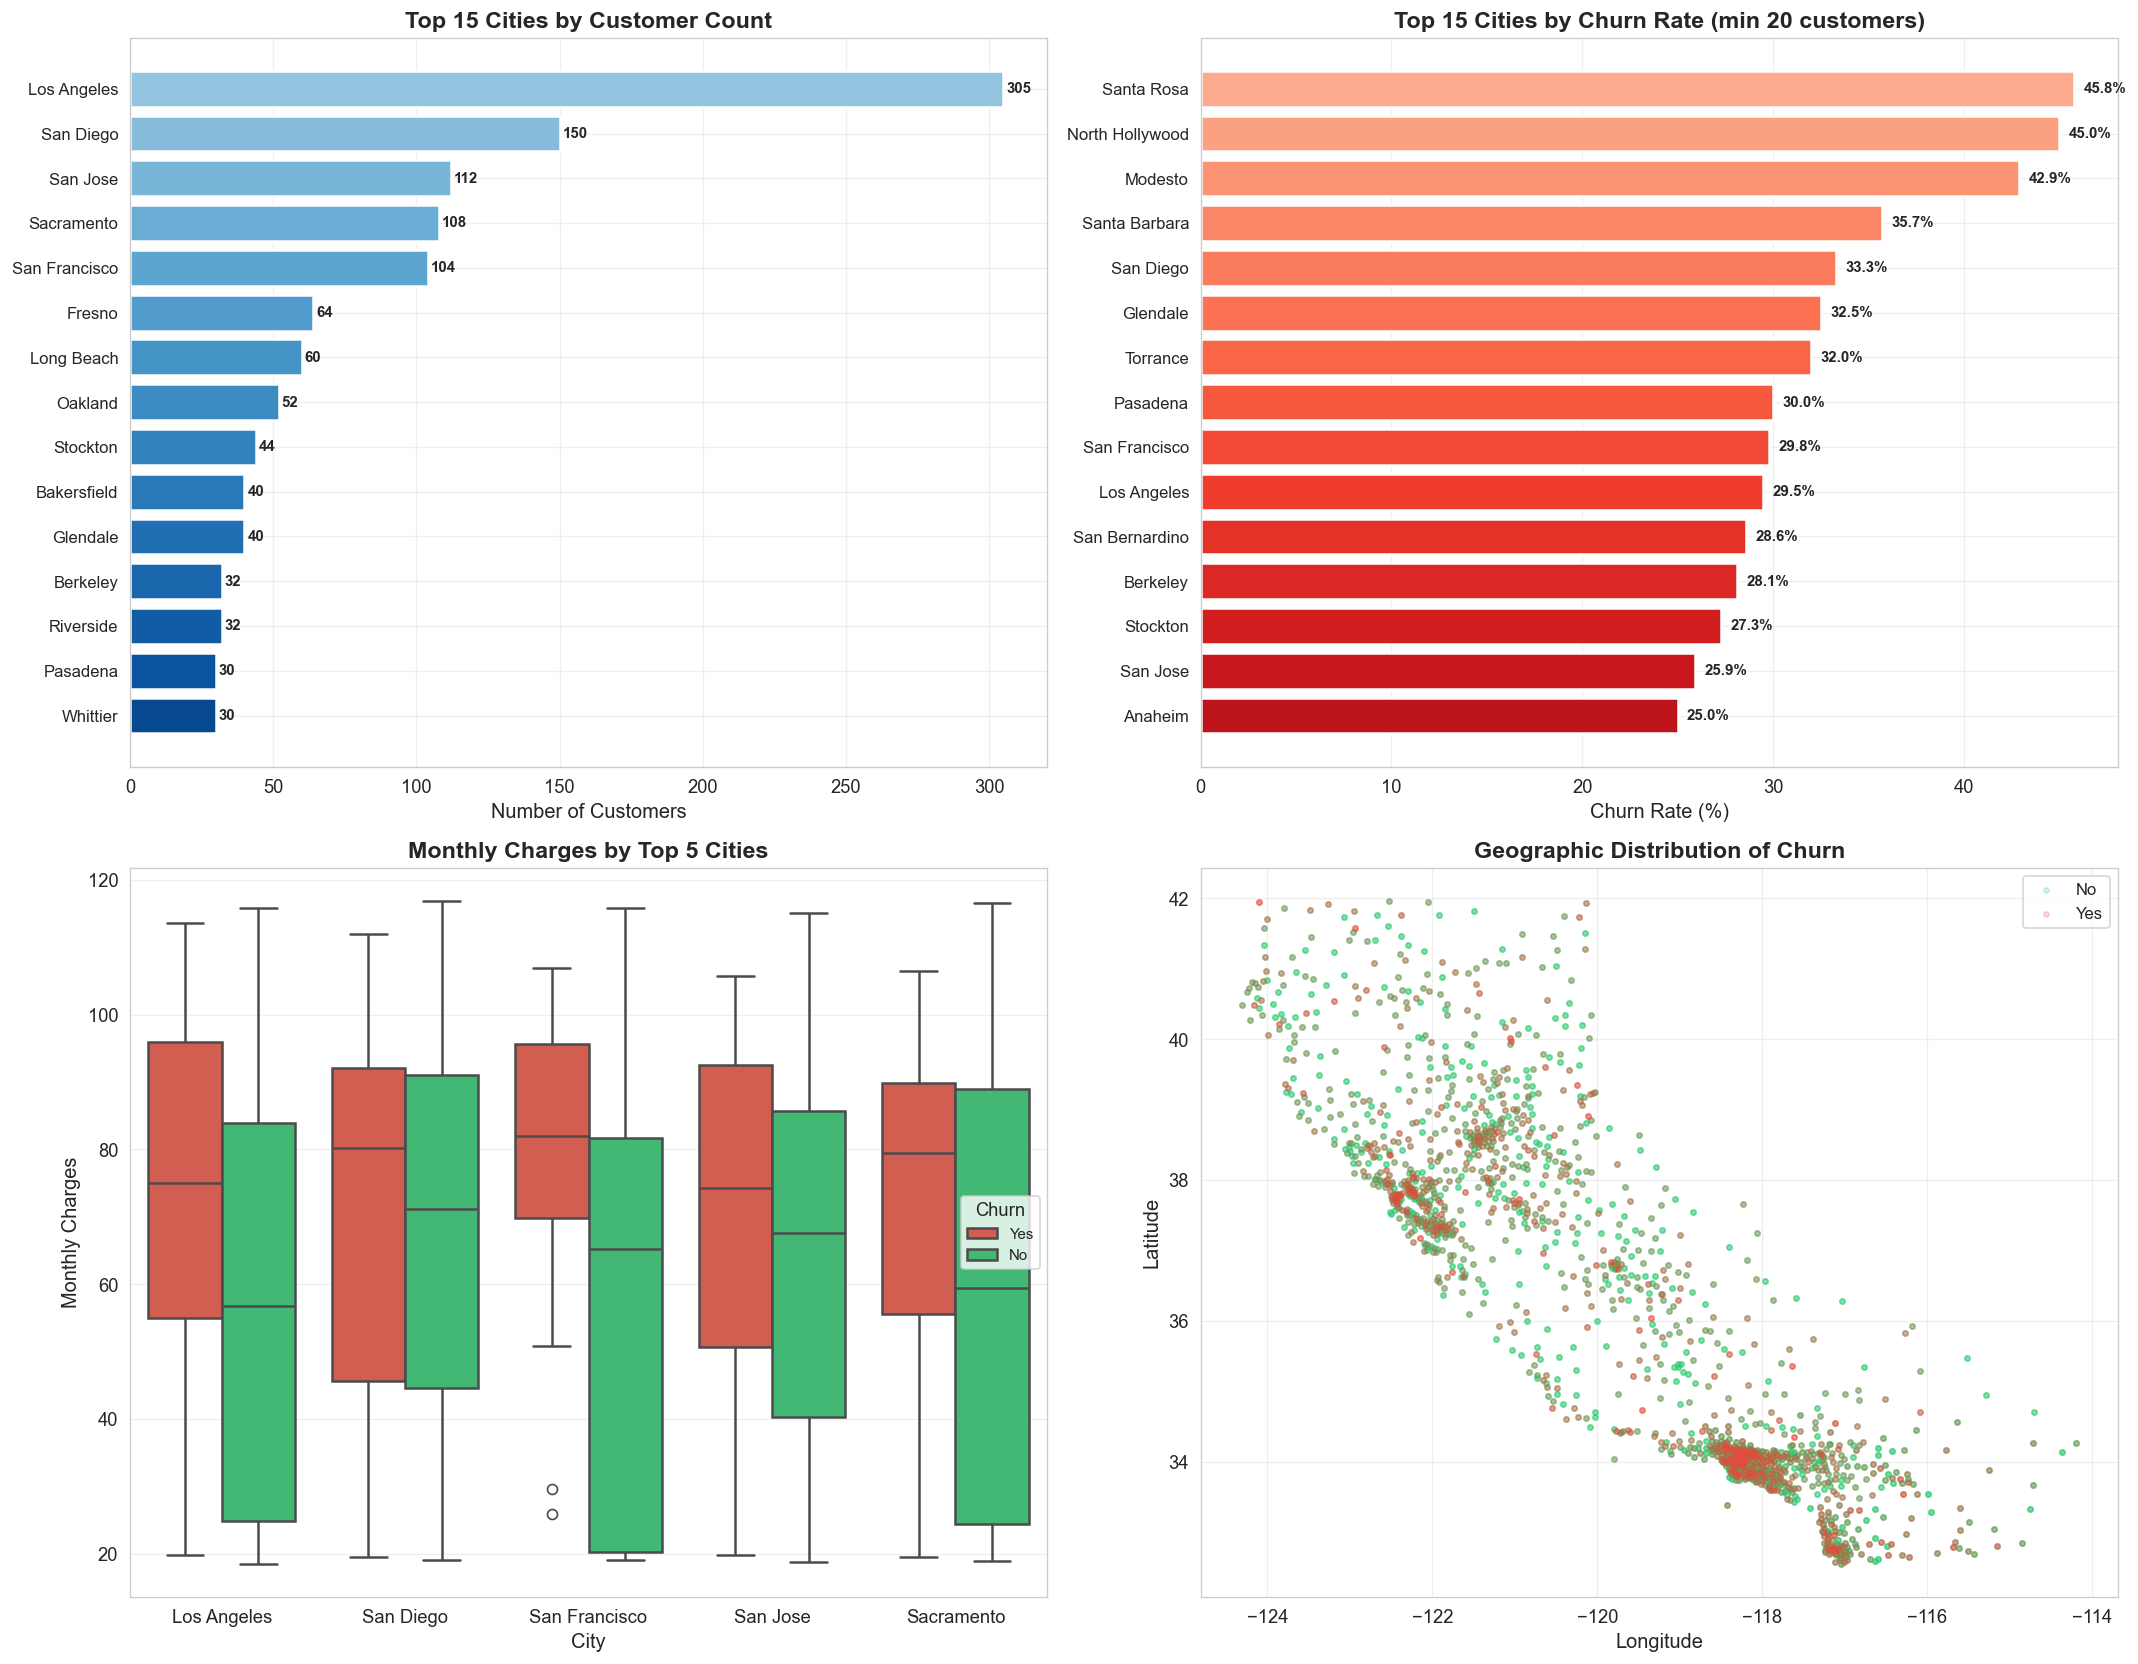

In [26]:
city_stats = df.groupby('City').agg(
    Customers=('CustomerID', 'count'),
    Churned=('Churn Value', 'sum'),
    Avg_Monthly=('Monthly Charges', 'mean'),
    Avg_Tenure=('Tenure Months', 'mean')
).reset_index()
city_stats['Churn_Rate'] = (city_stats['Churned'] / city_stats['Customers'] * 100).round(1)

fig, axes = plt.subplots(2, 2, figsize=(18, 14))
# Top cities by customer count
top_cust = city_stats.nlargest(15, 'Customers')
bars = axes[0][0].barh(range(len(top_cust)), top_cust['Customers'],
                        color=plt.cm.Blues(np.linspace(0.4, 0.9, len(top_cust))),
                        edgecolor='white', linewidth=1.5)
axes[0][0].set_yticks(range(len(top_cust)))
axes[0][0].set_yticklabels(top_cust['City'], fontsize=10)
axes[0][0].invert_yaxis()
axes[0][0].set_xlabel('Number of Customers')
axes[0][0].set_title('Top 15 Cities by Customer Count', fontweight='bold')
for i, val in enumerate(top_cust['Customers']):
    axes[0][0].text(val + 1, i, str(val), va='center', fontsize=9, fontweight='bold')

# Top cities by churn rate (min 20 customers)
top_churn = city_stats[city_stats['Customers'] >= 20].nlargest(15, 'Churn_Rate')
bars = axes[0][1].barh(range(len(top_churn)), top_churn['Churn_Rate'],
                        color=plt.cm.Reds(np.linspace(0.3, 0.8, len(top_churn))),
                        edgecolor='white', linewidth=1.5)
axes[0][1].set_yticks(range(len(top_churn)))
axes[0][1].set_yticklabels(top_churn['City'], fontsize=10)
axes[0][1].invert_yaxis()
axes[0][1].set_xlabel('Churn Rate (%)')
axes[0][1].set_title('Top 15 Cities by Churn Rate (min 20 customers)', fontweight='bold')
for i, val in enumerate(top_churn['Churn_Rate']):
    axes[0][1].text(val + 0.5, i, f'{val}%', va='center', fontsize=9, fontweight='bold')

# Monthly charges distribution by top 5 cities
top5_cities = city_stats.nlargest(5, 'Customers')['City'].tolist()
df_top5 = df[df['City'].isin(top5_cities)]
sns.boxplot(data=df_top5, x='City', y='Monthly Charges', hue='Churn Label',
            palette=CHURN_MAP, ax=axes[1][0], linewidth=1.5)
axes[1][0].set_title('Monthly Charges by Top 5 Cities', fontweight='bold')
axes[1][0].legend(title='Churn', fontsize=9)

# Geographic scatter (latitude/longitude colored by churn)
for lbl, color in CHURN_MAP.items():
    subset = df[df['Churn Label'] == lbl]
    axes[1][1].scatter(subset['Longitude'], subset['Latitude'],
                       alpha=0.2, color=color, label=lbl, s=10)
axes[1][1].set_xlabel('Longitude')
axes[1][1].set_ylabel('Latitude')
axes[1][1].set_title('Geographic Distribution of Churn', fontweight='bold')
axes[1][1].legend(fontsize=10)

plt.tight_layout()
plt.show()

Los Angeles has the highest customer volume (305) with a moderate churn rate of 29.5%, while smaller cities like Santa Rosa and North Hollywood show much higher churn rates (~45-46%) despite fewer customers, indicating localized service issues. Monthly charges are consistently higher for churned customers across all major cities, confirming price sensitivity as a universal driver. Geographically, churn is evenly distributed across Southern California and the Bay Area, with no rural concentration.

### **12. Statistical Summary**

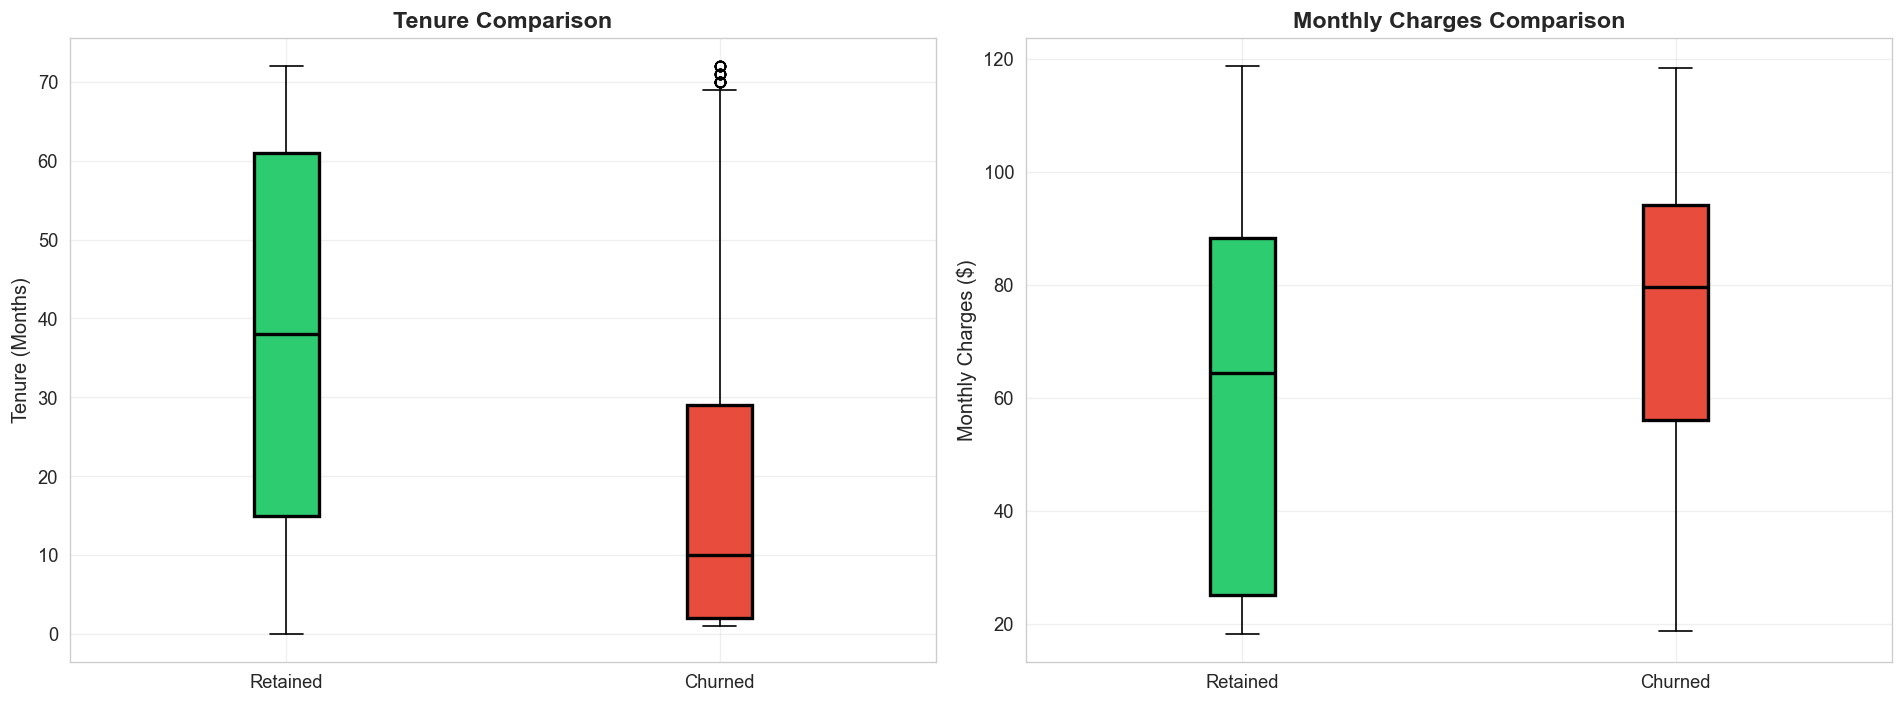

=== Descriptive Statistics: Retained vs Churned ===


Tenure Months                       Monthly Charges                              Total Charges                                       CLTV                              Churn Score         \
                     mean median    std min max            mean median    std    min     max          mean   median      std    min      max     mean  median      std   min   max        mean median   
Churn Label                                                                                                                                                                                             
No                  37.57   38.0  24.11   0  72           61.27  64.43  31.09  18.25  118.75       2555.34  1683.60  2329.46  18.80  8672.45  4490.92  4620.0  1167.70  2003  6500       50.10   50.0   
Yes                 17.98   10.0  19.53   1  72           74.44  79.65  24.67  18.85  118.35       1531.80   703.55  1890.82  18.85  8684.80  4149.41  4238.0  1189.37  2003  6484       82.51   82.0   

                             
               std min  max  
Churn Label                  
No           17.70   5   80  
Yes          10.33  65  100

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Tenure comparison
churned_tenure = df[df['Churn Label'] == 'Yes']['Tenure Months']
retained_tenure = df[df['Churn Label'] == 'No']['Tenure Months']

bp1 = axes[0].boxplot([retained_tenure, churned_tenure], labels=['Retained', 'Churned'],
                      patch_artist=True, boxprops=dict(linewidth=2),
                      medianprops=dict(color='black', linewidth=2))
bp1['boxes'][0].set_facecolor(C_RETAIN)
bp1['boxes'][1].set_facecolor(C_CHURN)
axes[0].set_ylabel('Tenure (Months)')
axes[0].set_title('Tenure Comparison', fontweight='bold')

# Monthly charges comparison
churned_mc = df[df['Churn Label'] == 'Yes']['Monthly Charges']
retained_mc = df[df['Churn Label'] == 'No']['Monthly Charges']

bp2 = axes[1].boxplot([retained_mc, churned_mc], labels=['Retained', 'Churned'],
                      patch_artist=True, boxprops=dict(linewidth=2),
                      medianprops=dict(color='black', linewidth=2))
bp2['boxes'][0].set_facecolor(C_RETAIN)
bp2['boxes'][1].set_facecolor(C_CHURN)
axes[1].set_ylabel('Monthly Charges ($)')
axes[1].set_title('Monthly Charges Comparison', fontweight='bold')

plt.tight_layout()
plt.show()

# Summary statistics table
print('=== Descriptive Statistics: Retained vs Churned ===')
summary = df.groupby('Churn Label')[NUMERIC_COLS + ['CLTV', 'Churn Score']].agg(
    ['mean', 'median', 'std', 'min', 'max']
).round(2)
summary

### **🌟 Exploratory Feature Importance Analysis**

Although the final machine learning models will be trained after proper data preprocessing and feature engineering, an initial feature importance analysis can provide valuable insights into which variables are most strongly associated with customer churn.

For this exploratory analysis:

- A lightweight Random Forest classifier is used.
- Simple preprocessing is applied solely for visualization purposes.
- Results are **not** used for model selection or evaluation.
- The objective is to identify potentially influential features before the formal preprocessing pipeline.

> **Note:** This analysis is exploratory only. Feature importance values may change after feature engineering, encoding, and hyperparameter tuning.

In [28]:
feature_df = df.copy()
feature_df = feature_df.drop(columns=[col for col in leakage_cols if col in feature_df.columns])
location_columns = ["Zip Code", "Lat Long", "City", "Latitude", "Longitude", "CustomerID"]
feature_df = feature_df.drop(columns=[col for col in location_columns if col in feature_df.columns])

target_column = "Churn Label"
X = feature_df
y = df[target_column]

# Convert target to binary if necessary
if y.dtype == "object":
    y = y.map({"Yes": 1, "No": 0})


numeric_features = X.select_dtypes(include=["number"]).columns.tolist()
categorical_features = X.select_dtypes(exclude=["number"]).columns.tolist()
numeric_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
categorical_transformer = Pipeline(steps=[("imputer", SimpleImputer(strategy="most_frequent")),
                                          ("encoder", OneHotEncoder(handle_unknown="ignore"))])
preprocessor = ColumnTransformer(transformers=[("num", numeric_transformer, numeric_features),
                                               ("cat", categorical_transformer, categorical_features)])
rf = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
pipeline = Pipeline(steps=[("preprocessor", preprocessor), ("model", rf)])
pipeline.fit(X, y)
encoded_features = pipeline.named_steps["preprocessor"].get_feature_names_out()
importance_df = pd.DataFrame({"Feature": encoded_features, "Importance": pipeline.named_steps["model"].feature_importances_})

original_names = []

for feature in importance_df["Feature"]:
    feature = feature.replace("num__", "")
    feature = feature.replace("cat__", "")
    matched = False
    for col in categorical_features:
        prefix = col + "_"
        if feature.startswith(prefix):
            original_names.append(col)
            matched = True
            break
    if not matched:
        original_names.append(feature)

importance_df["Original Feature"] = original_names
feature_importance = (importance_df.groupby("Original Feature", as_index=False)["Importance"]
                      .sum().sort_values("Importance", ascending=False))

feature_importance.head(15)

,Original Feature,Importance
21,Total Charges,0.158129
7,Monthly Charges,0.137003
20,Tenure Months,0.134083
0,Contract,0.084389
13,Payment Method,0.063646
10,Online Security,0.043679
19,Tech Support,0.041339
3,Dependents,0.039934
6,Internet Service,0.035733
5,Gender,0.034201


In [29]:
top_features = feature_importance.head(15)
fig = px.bar(top_features[::-1], x="Importance", y="Original Feature",
             orientation="h", text="Importance", 
             title="Exploratory Feature Importance (Random Forest Baseline)",
             template="plotly_white")
fig.update_traces(texttemplate="%{text:.3f}")
fig.update_layout(title_x=0.5, height=650, xaxis_title="Feature Importance", yaxis_title="")
fig.show()

#### **📌 Exploratory Feature Importance Analysis**

To complement the statistical analyses and visual exploration, an exploratory **Random Forest** model was trained to estimate the relative importance of each feature. This analysis is intended solely to provide an initial understanding of which variables may contribute most to churn prediction before applying the complete preprocessing and modeling pipeline.

#### Key Findings

- **Total Charges**, **Monthly Charges**, and **Tenure Months** are the three most influential features, indicating that customer lifetime value, billing behavior, and subscription duration are strongly associated with churn.
- **Contract Type** also exhibits high importance, supporting the earlier exploratory analysis that customers with month-to-month contracts are generally more likely to churn than those with longer-term agreements.
- Service-related variables such as **Online Security**, **Tech Support**, and **Internet Service** rank among the most important predictors, suggesting that the subscribed services have a meaningful impact on customer retention.
- Customer relationship indicators including **Dependents** and **Partner** also contribute to the prediction, although their influence is lower than financial and contractual variables.
- Demographic variables such as **Gender** appear to have relatively limited predictive power compared with financial and service-related attributes.

#### Interpretation

The feature importance results are highly consistent with the patterns observed throughout the exploratory data analysis. Financial characteristics, contract information, and service subscriptions appear to be the primary drivers of customer churn, while purely demographic information contributes comparatively less.

> **Note:** This feature importance analysis is exploratory only. It was performed using a baseline Random Forest model prior to the complete preprocessing pipeline. The importance rankings may change after feature engineering, feature selection, and hyperparameter optimization during the model development stage.

### **Results Summary — Telco Churn Analysis**

**Dataset:** 7,043 customers, 33 features | **Churn Rate:** 26.5% | **Balance:** 2.77:1

**Key Findings:**
- Month-to-month contracts: 42.7% churn (dominant driver)
- Fiber optic: 41.9% churn vs ~18% DSL
- No Online Security: 41.8% churn
- Senior citizens: 41.7% vs 23.6% non-senior
- Top reason: Competitor offer (~30%)
- Highest risk: New customers (0–12 months) with high charges
- Tenure & Total Charges correlated (r > 0.8)

**Top Drivers:** Contract > Internet Service > Online Security > Tenure > Monthly Charges

**Data Notes:** `Total Charges` (11 nulls), `Churn Reason` (5,174 nulls), constant columns (`Count`, `Country`, `State`) redundant — safe to drop.

## **Make v2 Dataset(Cleaning Version)**

**Goal:** Transform raw data into two cleaned versions ready for model training.

| Version | Stage | Actions |
|---------|-------|---------|
| **v1** | Raw | Original data (already exists) |
| **v2** | Cleaning | Drop redundant columns, fix dtypes, handle nulls, encode categoricals |
| **v3** | Feature Engineering | Create new features, scale numerical data |

In [30]:
df_v2 = df.copy()
print(f'Starting v2 cleaning: {df_v2.shape[0]:,} rows x {df_v2.shape[1]} columns')
print(f'Memory before: {df_v2.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Starting v2 cleaning: 7,043 rows x 33 columns
Memory before: 9.6 MB


### **1. Drop Redundant / Non-Predictive Columns**

In [31]:
DROP_COLS = [
    'CustomerID',        # unique identifier, not predictive
    'Count',             # constant (=1 for all rows)
    'Country',           # constant ('United States' for all rows)
    'State',             # constant ('California' for all rows)
    'Zip Code',          # lots of unique value
    'City',              # lots of unique value & redundant with Lat/Long
    'Lat Long',          # redundant with Latitude + Longitude
    'Churn Label',       # text duplicate of Churn Value
    'Churn Score',       # ML-generated score, potential data leakage
    'CLTV',              # post-churn metric, potential data leakage
    'Churn Reason',      # only available after churn happens (not at prediction time)
]

print('Dropping columns:')
reasons = {
    'CustomerID': 'unique identifier',
    'Count': 'constant (=1)',
    'Country': 'constant (US)',
    'State': 'constant (California)',
    'Zip Code': 'very unique values & redundant with Lat/Long',
    'City' : 'very unique values & redundant with Lat/Long',
    'Lat Long': 'redundant with Lat/Lon',
    'Churn Label': 'text duplicate of Churn Value',
    'Churn Score': 'ML-generated, data leakage risk',
    'CLTV': 'post-churn metric, leakage risk',
    'Churn Reason': 'only for churned customers, not available at prediction time',
}
for col in DROP_COLS:
    print(f'  {col:25s} -> {reasons[col]}')

df_v2 = df_v2.drop(columns=DROP_COLS)
print(f'\nAfter dropping: {df_v2.shape[1]} columns remain')

Dropping columns:
  CustomerID                -> unique identifier
  Count                     -> constant (=1)
  Country                   -> constant (US)
  State                     -> constant (California)
  Zip Code                  -> very unique values & redundant with Lat/Long
  City                      -> very unique values & redundant with Lat/Long
  Lat Long                  -> redundant with Lat/Lon
  Churn Label               -> text duplicate of Churn Value
  Churn Score               -> ML-generated, data leakage risk
  CLTV                      -> post-churn metric, leakage risk
  Churn Reason              -> only for churned customers, not available at prediction time

After dropping: 22 columns remain


In [32]:
df_v2.head(3)

,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,33.964131,-118.272783,Male,No,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
1,34.059281,-118.307420,Female,No,No,Yes,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
2,34.048013,-118.293953,Female,No,No,Yes,8,Yes,Yes,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,99.65,820.50,1


### **2. Handling Missing Values**

In [33]:
# Check missing values before handling
null_summary = df_v2.isnull().sum()
null_summary = null_summary[null_summary > 0]

if len(null_summary) > 0:
    print('Missing values found:')
    for col, count in null_summary.items():
        pct = count / len(df_v2) * 100
        print(f'  {col}: {count} ({pct:.2f}%)')
else:
    print('No missing values found.')

Missing values found:
  Total Charges: 11 (0.16%)


In [34]:
# Strategy: Drop rows with null Total Charges (only 11 rows, ~0.16%)
# These are customers with 0 tenure who haven't been billed yet
before = len(df_v2)
df_v2 = df_v2.dropna(subset=['Total Charges'])
after = len(df_v2)
print(f'Dropped {before - after} rows with null Total Charges')
print(f'Remaining: {after:,} rows')
print(f'Null check: {df_v2.isnull().sum().sum()} total nulls remaining')

Dropped 11 rows with null Total Charges
Remaining: 7,032 rows
Null check: 0 total nulls remaining


Rows with null values in `Total Charges` (11 records, ~0.16% of the dataset) were dropped due to their negligible impact on overall analysis.

### **3. Encode Categorical Variables**

In [35]:
# Identify column types
cat_cols = df_v2.select_dtypes(include='object').columns.tolist()
num_cols = df_v2.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical columns to encode:')
for col in cat_cols:
    vals = df_v2[col].unique()
    print(f'  {col:25s} ({len(vals)} unique): {list(vals)[:6]}')

print(f'\nNumerical columns: {num_cols}')

Categorical columns to encode:
  Gender                    (2 unique): ['Male', 'Female']
  Senior Citizen            (2 unique): ['No', 'Yes']
  Partner                   (2 unique): ['No', 'Yes']
  Dependents                (2 unique): ['No', 'Yes']
  Phone Service             (2 unique): ['Yes', 'No']
  Multiple Lines            (3 unique): ['No', 'Yes', 'No phone service']
  Internet Service          (3 unique): ['DSL', 'Fiber optic', 'No']
  Online Security           (3 unique): ['Yes', 'No', 'No internet service']
  Online Backup             (3 unique): ['Yes', 'No', 'No internet service']
  Device Protection         (3 unique): ['No', 'Yes', 'No internet service']
  Tech Support              (3 unique): ['No', 'Yes', 'No internet service']
  Streaming TV              (3 unique): ['No', 'Yes', 'No internet service']
  Streaming Movies          (3 unique): ['No', 'Yes', 'No internet service']
  Contract                  (3 unique): ['Month-to-month', 'Two year', 'One year']
  Pape

In [36]:
# Binary encoding for Yes/No columns
BINARY_MAP = {'Yes': 1, 'No': 0}
BINARY_COLS = [c for c in cat_cols if set(df_v2[c].unique()).issubset({'Yes', 'No'})]

print('Binary encoding (Yes=1, No=0):')
for col in BINARY_COLS:
    df_v2[col] = df_v2[col].map(BINARY_MAP)
    print(f'  {col}: {df_v2[col].unique()}')

print(f'\nEncoded {len(BINARY_COLS)} binary columns')

Binary encoding (Yes=1, No=0):
  Senior Citizen: [0 1]
  Partner: [0 1]
  Dependents: [0 1]
  Phone Service: [1 0]
  Paperless Billing: [1 0]

Encoded 5 binary columns


In [37]:
# Label Encoding for multi-category columns
MULTI_CAT_COLS = [c for c in cat_cols if c not in BINARY_COLS]

print('Label Encoding:')
le = LabelEncoder()
for col in MULTI_CAT_COLS:
    df_v2[col] = le.fit_transform(df_v2[col].astype(str))
    print(f'  {col:25s}: encoded')

print(f'\nFinal shape: {df_v2.shape[0]:,} rows x {df_v2.shape[1]} columns')

Label Encoding:
  Gender                   : encoded
  Multiple Lines           : encoded
  Internet Service         : encoded
  Online Security          : encoded
  Online Backup            : encoded
  Device Protection        : encoded
  Tech Support             : encoded
  Streaming TV             : encoded
  Streaming Movies         : encoded
  Contract                 : encoded
  Payment Method           : encoded

Final shape: 7,032 rows x 22 columns


In [38]:
# Verify v2 is fully numeric
non_numeric = df_v2.select_dtypes(exclude=['int64', 'float64', 'int32']).columns.tolist()
if non_numeric:
    print(f'WARNING: Non-numeric columns remaining: {non_numeric}')
else:
    print('v2 is fully numeric - all columns are int or float.')

print(f'v2 final shape: {df_v2.shape}')
print(f'Memory: {df_v2.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df_v2.head(3)

v2 is fully numeric - all columns are int or float.
v2 final shape: (7032, 22)
Memory: 1.3 MB


,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value
0,33.964131,-118.272783,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1
1,34.059281,-118.307420,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1
2,34.048013,-118.293953,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1


In [39]:
# Save v2
df_v2.to_excel('../data/v2/telco_customer_churn_v2.xlsx', index=False)
print(f'v2 saved: {df_v2.shape[0]:,} rows x {df_v2.shape[1]} columns')
print(f'  XLSX: ../data/v2/telco_customer_churn_v2.xlsx')

v2 saved: 7,032 rows x 22 columns
  XLSX: ../data/v2/telco_customer_churn_v2.xlsx


## **Make v3 Dataset(Feature Engineering)**

Feature engineering is one of the most critical stages in the machine learning workflow. Rather than relying solely on the original variables, this step creates new informative features that better represent customer behavior, financial characteristics, and service usage patterns.

The objective of this version (`v3`) is to transform the cleaned dataset into a richer representation while preserving the original information whenever possible.

The feature engineering process includes:

- Removing target leakage variables
- Removing non-informative identifier columns
- Creating financial features
- Creating customer engagement features
- Creating service-related aggregations
- Creating contract-related indicators
- Creating customer risk indicators
- Creating interaction features
- Preparing the dataset for the preprocessing pipeline

> **Important:** No feature scaling is performed in this section. This transformations belong to the machine learning pipeline to avoid data leakage.

In [40]:
# Start from v1
df_v3 = df.copy()
print(f'Starting v3 from v2: {df_v3.shape[0]:,} rows x {df_v3.shape[1]} columns')

Starting v3 from v2: 7,043 rows x 33 columns


### **1. Remove Non-Predictive Features**

Several variables either leak information about the target variable or do not contribute meaningful predictive information. These variables are removed before constructing new features.

In [41]:
# Remove Target Leakage Features
leakage_cols = [x for x in leakage_cols if x not in ['Churn Value', 'CLTV']]
df_v3.drop(columns=[c for c in leakage_cols if c in df_v3.columns], inplace=True)

# Remove Identifier Columns
identifier_columns = ["CustomerID"]
df_v3.drop(columns=[c for c in identifier_columns if c in df_v3.columns], inplace=True)
print(f"Dataset Shape: {df_v3.shape}")

Dataset Shape: (7043, 29)


In [42]:
df_v3.tail(2)

,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV
7041,1,United States,California,Angelus Oaks,92305,"34.1678, -116.86433",34.167800,-116.864330,Female,No,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0,2793
7042,1,United States,California,Apple Valley,92308,"34.424926, -117.184503",34.424926,-117.184503,Male,No,No,No,66,Yes,No,Fiber optic,Yes,No,Yes,Yes,Yes,Yes,Two year,Yes,Bank transfer (automatic),105.65,6844.50,0,5097


### **2. Payment Features**

Payment behavior is another important indicator of customer loyalty.

Electronic payments and paperless billing are converted into explicit binary indicators.

In [43]:
# Payment Features
df_v3["Uses_Auto_Payment"] = (df_v3["Payment Method"].isin(["Bank transfer (automatic)",
                                                             "Credit card (automatic)"])).astype(int)

### **3. Service-Based Features**

Customer subscriptions provide valuable information about engagement and product adoption.

Instead of treating every service independently, several aggregate features are created to summarize service usage patterns. These features improve interpretability while reducing the complexity of downstream models.

In [44]:
# Service Columns
service_columns = ["Phone Service", "Multiple Lines", "Internet Service", "Online Security",
                   "Online Backup", "Device Protection", "Tech Support", "Streaming TV", "Streaming Movies"]

# Convert "Yes" to 1 and everything else to 0
service_binary = pd.DataFrame(index=df_v3.index)
for col in service_columns:
    if col in df_v3.columns:
        service_binary[col] = (df_v3[col] == "Yes").astype(int)

In [45]:
# Total Active Services
df_v3["Service_Count"] = service_binary.sum(axis=1)

# Digital Security Score
security_features = ["Online Security", "Online Backup", "Device Protection", "Tech Support"]
available_security = [c for c in security_features if c in service_binary.columns]
df_v3["Security_Service_Count"] = (service_binary[available_security].sum(axis=1))

# Entertainment Score
entertainment_features = ["Streaming TV", "Streaming Movies"]
available_entertainment = [c for c in entertainment_features if c in service_binary.columns]
df_v3["Entertainment_Service_Count"] = (service_binary[available_entertainment].sum(axis=1))

### **4. Customer Loyalty Features**

Long-term customers generally exhibit lower churn rates than recently acquired customers.

Several indicators are created to capture customer loyalty and relationship duration.

In [46]:
# Customer Loyalty
df_v3["Is_New_Customer"] = (df_v3["Tenure Months"] <= 12).astype(int)
df_v3["Is_Long_Term_Customer"] = (df_v3["Tenure Months"] >= 48).astype(int)
df_v3["Tenure_Group"] = pd.cut(df_v3["Tenure Months"], bins=[0,12,24,48,72],
                        labels=["New", "Growing", "Established", "Loyal"],
                        include_lowest=True)

### **5. Customer Value Features**

Customer value is estimated by combining spending behavior with subscription duration.

These variables help distinguish between high-value and low-value customers.

In [47]:
# Spending Categories
df_v3["Monthly_Spending_Level"] = pd.qcut(df_v3["Monthly Charges"], q=4,
                                  labels=["Low", "Medium", "High", "Premium"])

### **6. Interaction Features**

Interaction features combine multiple customer characteristics into a single representation.

These variables frequently improve model performance by capturing relationships that individual features cannot represent alone.

In [48]:
# Contract & Spending
df_v3["MonthToMonth_HighCharge"] = (
    ((df_v3["Contract"] == "Month-to-month") &
     (df_v3["Monthly Charges"] > df_v3["Monthly Charges"].median())
    )).astype(int)

### **🔍 Feature Validation & Dataset Optimization**

At this stage, all engineered features have been created.

Before proceeding to preprocessing and model development, the dataset is validated to ensure that all features are meaningful, consistent, and free from obvious quality issues.

The validation process includes:

- Dataset integrity verification
- Missing value inspection
- Duplicate feature detection
- Constant feature detection
- High-cardinality feature identification
- Highly correlated feature analysis
- Final dataset summary

The objective is to guarantee that Version 3 is clean, reliable, and ready for machine learning.

In [49]:
# Dataset Overview
print("=" * 60)
print("Version 3 Dataset")
print("=" * 60)

print(f"Rows      : {df_v3.shape[0]:,}")
print(f"Columns   : {df_v3.shape[1]:,}")
print(f"Memory MB : {df_v3.memory_usage(deep=True).sum()/1024**2:.2f}")

Version 3 Dataset
Rows      : 7,043
Columns   : 38
Memory MB : 8.45


In [50]:
missing_summary = (pd.DataFrame({"Missing Values": df_v3.isna().sum(),
                                 "Missing (%)": (df_v3.isna().mean()*100).round(2)}).query("`Missing Values` > 0")
                                 .sort_values("Missing Values", ascending=False))
df_v3 = df_v3.dropna(axis=0)
display(missing_summary)
print(f"Columns with Missing Values: {len(missing_summary)}")

,Missing Values,Missing (%)
Total Charges,11,0.16


Columns with Missing Values: 1


In [51]:
constant_features = [col for col in df_v3.columns if df_v3[col].nunique(dropna=False) == 1]
print(f"Constant Features: {len(constant_features)}")
if constant_features:
    display(pd.DataFrame({"Constant Feature": constant_features}))
df_v3 = df_v3.drop(constant_features, axis=1)

Constant Features: 3


,Constant Feature
0,Count
1,Country
2,State


In [52]:
df_v3.shape

(7032, 35)

In [53]:
# Geographic Region
df_v3["Geo_Region"] = (df_v3["Latitude"].round(0).astype(str) + "_" + df_v3["Longitude"].round(0).astype(str))

# City Customer Density
city_counts = df_v3["City"].value_counts()
df_v3["City_Customer_Count"] = (df_v3["City"].map(city_counts))

geografical_cols = ['City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude']
df_v3 = df_v3.drop(columns=geografical_cols)

**Geographic Feature Engineering**

Two new features were created to retain geographic information while reducing dimensionality:  
- `Geo_Region`: Groups customers by rounded latitude and longitude coordinates, capturing broad regional patterns without high cardinality.  
- `City_Customer_Count`: Encodes city-level customer density as a numeric feature, preserving the effect of city size on churn behavior.  

After engineering, the original geographic columns (`City`, `Zip Code`, `Lat Long`, `Latitude`, `Longitude`) were dropped to avoid redundancy and high dimensionality, leaving a more compact and model-ready dataset.

### **High Cardinality Analysis**

Categorical variables with a very large number of unique values may increase model complexity and require special treatment during preprocessing.

In [54]:
categorical_columns = df_v3.select_dtypes(include="object").columns

cardinality = (pd.DataFrame({"Unique Values": df_v3[categorical_columns].nunique()})
                             .sort_values("Unique Values", ascending=False))

display(cardinality)

,Unique Values
Geo_Region,57
Payment Method,4
Streaming Movies,3
Online Backup,3
Online Security,3
Tech Support,3
Device Protection,3
Internet Service,3
Multiple Lines,3
Contract,3


In [55]:
df_v3.shape

(7032, 32)

In [56]:
duplicate_columns = []

columns = df_v3.columns.tolist()

for i in range(len(columns)):
    for j in range(i + 1, len(columns)):
        if df_v3[columns[i]].equals(df_v3[columns[j]]):
            duplicate_columns.append((columns[i], columns[j]))

print(f"Duplicate Feature Pairs: {len(duplicate_columns)}")

if duplicate_columns:display(pd.DataFrame(duplicate_columns, columns=["Feature A", "Feature B"]))

Duplicate Feature Pairs: 0


In [57]:
numeric_columns = df_v3.select_dtypes(include="number").columns
corr_matrix = df_v3[numeric_columns].corr().abs()

upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr = (upper.stack().reset_index())
high_corr.columns = ["Feature A", "Feature B", "Correlation"]
high_corr = (high_corr.query("Correlation >= 0.90").sort_values("Correlation", ascending=False))

display(high_corr)

,Feature A,Feature B,Correlation


In [58]:
summary = pd.DataFrame({
    "Data Type": df_v3.dtypes,
    "Missing": df_v3.isna().sum(),
    "Unique": df_v3.nunique()
})

display(summary)

,Data Type,Missing,Unique
Gender,object,0,2
Senior Citizen,object,0,2
Partner,object,0,2
Dependents,object,0,2
Tenure Months,int64,0,72
Phone Service,object,0,2
Multiple Lines,object,0,3
Internet Service,object,0,3
Online Security,object,0,3
Online Backup,object,0,3


In [59]:
# Identify column types
cat_cols = df_v3.select_dtypes(include=['object', 'category']).columns.tolist()
num_cols = df_v3.select_dtypes(include=['int64', 'float64']).columns.tolist()

print('Categorical columns to encode:')
for col in cat_cols:
    vals = df_v3[col].unique()
    print(f'  {col:25s} ({len(vals)} unique): {list(vals)[:6]}')

print(f'\nNumerical columns: {num_cols}')

Categorical columns to encode:
  Gender                    (2 unique): ['Male', 'Female']
  Senior Citizen            (2 unique): ['No', 'Yes']
  Partner                   (2 unique): ['No', 'Yes']
  Dependents                (2 unique): ['No', 'Yes']
  Phone Service             (2 unique): ['Yes', 'No']
  Multiple Lines            (3 unique): ['No', 'Yes', 'No phone service']
  Internet Service          (3 unique): ['DSL', 'Fiber optic', 'No']
  Online Security           (3 unique): ['Yes', 'No', 'No internet service']
  Online Backup             (3 unique): ['Yes', 'No', 'No internet service']
  Device Protection         (3 unique): ['No', 'Yes', 'No internet service']
  Tech Support              (3 unique): ['No', 'Yes', 'No internet service']
  Streaming TV              (3 unique): ['No', 'Yes', 'No internet service']
  Streaming Movies          (3 unique): ['No', 'Yes', 'No internet service']
  Contract                  (3 unique): ['Month-to-month', 'Two year', 'One year']
  Pape

In [60]:
# Binary encoding for Yes/No columns
BINARY_MAP = {'Yes': 1, 'No': 0}
BINARY_COLS = [c for c in cat_cols if set(df_v3[c].unique()).issubset({'Yes', 'No'})]

print('Binary encoding (Yes=1, No=0):')
for col in BINARY_COLS:
    df_v3[col] = df_v3[col].map(BINARY_MAP)
    print(f'  {col}: {df_v3[col].unique()}')

print(f'\nEncoded {len(BINARY_COLS)} binary columns')

Binary encoding (Yes=1, No=0):
  Senior Citizen: [0 1]
  Partner: [0 1]
  Dependents: [0 1]
  Phone Service: [1 0]
  Paperless Billing: [1 0]

Encoded 5 binary columns


In [61]:
# Label Encoding for multi-category columns
MULTI_CAT_COLS = [c for c in cat_cols if c not in BINARY_COLS]

print('Label Encoding:')
le = LabelEncoder()
for col in MULTI_CAT_COLS:
    df_v3[col] = le.fit_transform(df_v3[col].astype(str))
    print(f'  {col:25s}: encoded')

print(f'\nFinal shape: {df_v3.shape[0]:,} rows x {df_v3.shape[1]} columns')

Label Encoding:
  Gender                   : encoded
  Multiple Lines           : encoded
  Internet Service         : encoded
  Online Security          : encoded
  Online Backup            : encoded
  Device Protection        : encoded
  Tech Support             : encoded
  Streaming TV             : encoded
  Streaming Movies         : encoded
  Contract                 : encoded
  Payment Method           : encoded
  Tenure_Group             : encoded
  Monthly_Spending_Level   : encoded
  Geo_Region               : encoded

Final shape: 7,032 rows x 32 columns


In [62]:
# Verify v3 is fully numeric
non_numeric = df_v3.select_dtypes(exclude=['int64', 'float64', 'int32']).columns.tolist()
if non_numeric:
    print(f'WARNING: Non-numeric columns remaining: {non_numeric}')
else:
    print('v3 is fully numeric - all columns are int or float.')

print(f'v3 final shape: {df_v3.shape}')
print(f'Memory: {df_v3.memory_usage(deep=True).sum() / 1e6:.1f} MB')
df_v3.head(3)

v3 is fully numeric - all columns are int or float.
v3 final shape: (7032, 32)
Memory: 1.9 MB


,Gender,Senior Citizen,Partner,Dependents,Tenure Months,Phone Service,Multiple Lines,Internet Service,Online Security,Online Backup,Device Protection,Tech Support,Streaming TV,Streaming Movies,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Value,CLTV,Uses_Auto_Payment,Service_Count,Security_Service_Count,Entertainment_Service_Count,Is_New_Customer,Is_Long_Term_Customer,Tenure_Group,Monthly_Spending_Level,MonthToMonth_HighCharge,Geo_Region,City_Customer_Count
0,1,0,0,0,2,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15,1,3239,0,3,2,0,1,0,3,2,0,8,304
1,0,0,0,1,2,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65,1,2701,0,1,0,0,1,0,3,0,1,8,304
2,0,0,0,1,8,1,2,1,0,0,2,0,2,2,0,1,2,99.65,820.50,1,5372,0,5,1,2,1,0,3,3,1,8,304


In [63]:
# Save v3
df_v3.to_excel('../data/v3/telco_customer_churn_v3.xlsx', index=False)
print(f'v3 saved: {df_v3.shape[0]:,} rows x {df_v3.shape[1]} columns')
print(f'  XLSX: ../data/v3/telco_customer_churn_v3.xlsx')

v3 saved: 7,032 rows x 32 columns
  XLSX: ../data/v3/telco_customer_churn_v3.xlsx


## **Model Training & Evaluation with MLflow**

- Train multiple ML models on v3 data
- Use Cross Validation (K-Fold) to prevent overfitting
- Split data: train / validation / test
- Log all experiments to MLflow (model name, hyperparameters, dataset version, metrics, seed)
- Final evaluation on test set only once

#### Models
| # | Model | Type |
|---|-------|------|
| 1 | Logistic Regression | Linear |
| 2 | Random Forest | Ensemble (Bagging) |
| 3 | XGBoost | Gradient Boosting |
| 4 | CatBoost | Gradient Boosting |
| 5 | LightGBM | Gradient Boosting |
| 6 | Gradient Boosting (sklearn) | Gradient Boosting |
| 7 | AdaBoost | Boosting |

In [58]:
# Load v2, v3 data (cleaned + engineered)
df_v2 = pd.read_excel('../data/v2/telco_customer_churn_v2.xlsx')
print(f'v2 data loaded: {df_v2.shape[0]:,} rows x {df_v2.shape[1]} columns')
df_v3 = pd.read_excel('../data/v3/telco_customer_churn_v3.xlsx')
print(f'v3 data loaded: {df_v3.shape[0]:,} rows x {df_v3.shape[1]} columns')

print('\n--- v2 Dataset Info ---')
print(f'Columns: {df_v2.columns.tolist()}')
print(f'Missing values:\n{df_v2.isnull().sum()}')
print(f'Target distribution:\n{df_v2["Churn Value"].value_counts()}')

print('\n--- v3 Dataset Info ---')
print(f'Columns: {df_v3.columns.tolist()}')
print(f'Missing values:\n{df_v3.isnull().sum()}')
print(f'Target distribution:\n{df_v3["Churn Value"].value_counts()}')

v2 data loaded: 7,032 rows x 22 columns
v3 data loaded: 7,032 rows x 32 columns

--- v2 Dataset Info ---
Columns: ['Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Value']
Missing values:
Latitude             0
Longitude            0
Gender               0
Senior Citizen       0
Partner              0
Dependents           0
Tenure Months        0
Phone Service        0
Multiple Lines       0
Internet Service     0
Online Security      0
Online Backup        0
Device Protection    0
Tech Support         0
Streaming TV         0
Streaming Movies     0
Contract             0
Paperless Billing    0
Payment Method       0
Monthly Charges      0
Total Charges        0
Churn Value          0
dt

In [59]:
def create_preprocessor(df, target="Churn Value", scale_numeric=True):
    X = df.drop(columns=[target]).copy()
    y = df[target].copy()

    passthrough_features = [
        'Gender', 
        'Senior Citizen', 
        'Partner', 
        'Dependents', 
        'Phone Service', 
        'Contract', 
        'Paperless Billing'
    ]
    
    passthrough_features = [col for col in passthrough_features if col in X.columns]
    passthrough_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent"))
    ])
    remainder_pipeline = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler())
    ])

    if scale_numeric:
        preprocessor = ColumnTransformer(
            transformers=[
                ("keep_as_is", passthrough_pipeline, passthrough_features)
            ],
            remainder=remainder_pipeline 
        )
    else:
        preprocessor = ColumnTransformer(
            transformers=[("keep_as_is", passthrough_pipeline, passthrough_features)],
            remainder=Pipeline([("imputer", SimpleImputer(strategy="median"))])
        )

    return X, y, preprocessor

In [60]:
# Separate features and target
X_v2, y_v2, preprocessor_v2 = create_preprocessor(df_v2)
X_v3, y_v3, preprocessor_v3 = create_preprocessor(df_v3)

In [61]:
# Split: 85% train, 15% test (stratified)
RANDOM_SEED = 42

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.15, random_state=RANDOM_SEED, stratify=y_v2
)
X_train_v3, X_test_v3, y_train_v3, y_test_v3 = train_test_split(
    X_v3, y_v3, test_size=0.15, random_state=RANDOM_SEED, stratify=y_v3
)

print("="*50)
print("DATA SPLIT SUMMARY")
print("="*50)

print(f"\nTotal samples: {len(y_v2):,}")

print(f"\nVersion 2 (without engineered features):")
print(f"  Training set   : {len(y_train_v2):,} samples ({len(y_train_v2)/len(y_v2)*100:.1f}%)")
print(f"  Test set       : {len(y_test_v2):,} samples ({len(y_test_v2)/len(y_v2)*100:.1f}%)")

print(f"\nVersion 3 (with engineered features):")
print(f"  Training set   : {len(y_train_v3):,} samples ({len(y_train_v3)/len(y_v3)*100:.1f}%)")
print(f"  Test set       : {len(y_test_v3):,} samples ({len(y_test_v3)/len(y_v3)*100:.1f}%)")

print(f"\nStratified split (preserves churn ratio):")
print(f"  Train churn %  : {y_train_v2.mean()*100:.1f}%")
print(f"  Test churn %   : {y_test_v2.mean()*100:.1f}%")
print("="*50)

DATA SPLIT SUMMARY

Total samples: 7,032

Version 2 (without engineered features):
  Training set   : 5,977 samples (85.0%)
  Test set       : 1,055 samples (15.0%)

Version 3 (with engineered features):
  Training set   : 5,977 samples (85.0%)
  Test set       : 1,055 samples (15.0%)

Stratified split (preserves churn ratio):
  Train churn %  : 26.6%
  Test churn %   : 26.5%


In [62]:
# Define models with hyperparameters
MODELS = {
    'Logistic Regression': {
        'model': LogisticRegression(
            max_iter=1000, random_state=RANDOM_SEED, class_weight='balanced'
        ),
        'type': 'sklearn'
    },
    'Random Forest': {
        'model': RandomForestClassifier(
            n_estimators=600, max_depth=14, min_samples_split=10,
            min_samples_leaf=5, max_features="sqrt", random_state=RANDOM_SEED, n_jobs=-1,
            class_weight="balanced_subsample",
        ),
        'type': 'sklearn'
    },
    'XGBoost': {
        'model': xgb.XGBClassifier(
            n_estimators=500, max_depth=10, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            scale_pos_weight=(y_v3 == 0).sum() / (y_v3 == 1).sum(),
            random_state=RANDOM_SEED, eval_metric='logloss',
            use_label_encoder=False
        ),
        'type': 'xgboost'
    },
    'CatBoost': {
        'model': cb.CatBoostClassifier(
            iterations=800, depth=10, learning_rate=0.05,
            auto_class_weights='Balanced', random_seed=RANDOM_SEED,
            verbose=0
        ),
        'type': 'catboost'
    },
    'LightGBM': {
        'model': lgb.LGBMClassifier(
            n_estimators=1000, max_depth=12, learning_rate=0.05,
            subsample=0.8, colsample_bytree=0.8,
            is_unbalance=True, random_state=RANDOM_SEED,
            verbose=-1
        ),
        'type': 'lightgbm'
    },
    'Gradient Boosting': {
        'model': GradientBoostingClassifier(
            n_estimators=600, max_depth=8, learning_rate=0.05,
            subsample=0.8, random_state=RANDOM_SEED
        ),
        'type': 'sklearn'
    },
    'AdaBoost': {
        'model': AdaBoostClassifier(
            n_estimators=500, learning_rate=0.05,
            random_state=RANDOM_SEED
        ),
        'type': 'sklearn'
    },
}

print(f'Defined {len(MODELS)} models:')
for name, cfg in MODELS.items():
    print(f'  {name:<25s} ({cfg["type"]})')

Defined 7 models:
  Logistic Regression       (sklearn)
  Random Forest             (sklearn)
  XGBoost                   (xgboost)
  CatBoost                  (catboost)
  LightGBM                  (lightgbm)
  Gradient Boosting         (sklearn)
  AdaBoost                  (sklearn)


In [63]:
# Set MLflow tracking URI to sqlite
MLFLOW_DIR = '../mlruns'
os.makedirs(MLFLOW_DIR, exist_ok=True)
mlflow.set_tracking_uri(f'sqlite:///{os.path.abspath(MLFLOW_DIR)}/mlflow.db')

EXPERIMENT_NAME = 'Telco_Churn_Prediction'
mlflow.set_experiment(EXPERIMENT_NAME)

print(f'MLflow tracking URI: {mlflow.get_tracking_uri()}')
print(f'Experiment: {EXPERIMENT_NAME}')

MLflow tracking URI: sqlite:///d:\telco-customer-churn-prediction\mlruns/mlflow.db
Experiment: Telco_Churn_Prediction


In [64]:
DATASETS = {
    "v2": {
        "X_train": X_train_v2,
        "X_test": X_test_v2,
        "y_train": y_train_v2,
        "y_test": y_test_v2,
    },
    "v3": {
        "X_train": X_train_v3,
        "X_test": X_test_v3,
        "y_train": y_train_v3,
        "y_test": y_test_v3,
    }
}

results = []

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_SEED
)

In [65]:
print("=" * 120)
print(
    f'{"Dataset":<8}'
    f'{"Model":<25}'
    f'{"CV F1":>10}'
    f'{"Test Acc":>10}'
    f'{"Precision":>10}'
    f'{"Recall":>10}'
    f'{"F1":>10}'
    f'{"ROC AUC":>10}'
    f'{"Time":>10}'
)
print("=" * 120)

for dataset_name, data in DATASETS.items():
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    
    preprocessor = preprocessor_v2 if dataset_name == "v2" else preprocessor_v3

    for model_name, cfg in MODELS.items():
        model = cfg["model"]
        model_type = cfg["type"]

        run_name = f"{model_name.lower().replace(' ', '_')}_{dataset_name}_selective_standard_scaler"
        with mlflow.start_run(run_name=run_name):
            start_time = time.time()

            full_pipeline = SkiPipeline([('preprocessor', preprocessor), ('classifier', model)])
            
            # Cross Validation
            cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=cv, scoring="f1", n_jobs=-1)
            cv_mean = cv_scores.mean()
            cv_std = cv_scores.std()

            # Train
            full_pipeline.fit(X_train, y_train)

            # Test Prediction
            y_pred = full_pipeline.predict(X_test)
            y_prob = full_pipeline.predict_proba(X_test)[:, 1]

            # Metrics
            test_acc = accuracy_score(y_test, y_pred)
            test_prec = precision_score(y_test, y_pred)
            test_rec = recall_score(y_test, y_pred)
            test_f1 = f1_score(y_test, y_pred)
            test_auc = roc_auc_score(y_test, y_prob)

            cm = confusion_matrix(y_test, y_pred)
            elapsed = time.time() - start_time

            # Log Parameters
            mlflow.log_param("dataset", dataset_name)
            mlflow.log_param("model_name", model_name)
            mlflow.log_param("model_type", model_type)
            mlflow.log_param("random_seed", RANDOM_SEED)

            mlflow.log_param("train_samples", len(X_train))
            mlflow.log_param("test_samples", len(X_test))
            mlflow.log_param("n_features", X_train.shape[1])
            mlflow.log_param("cv_folds", cv.get_n_splits())
            params = model.get_params()
            clean_params = {}
            for key, value in params.items():
                if isinstance(value, (str, int, float, bool, type(None))):
                    clean_params[key] = value
                else:
                    clean_params[key] = str(value)
            mlflow.log_params(clean_params)

            # Log Metrics
            mlflow.log_metric("cv_f1_mean", cv_mean)
            mlflow.log_metric("cv_f1_std", cv_std)
            mlflow.log_metric("test_accuracy", test_acc)
            mlflow.log_metric("test_precision", test_prec)
            mlflow.log_metric("test_recall", test_rec)
            mlflow.log_metric("test_f1", test_f1)
            mlflow.log_metric("test_roc_auc", test_auc)
            mlflow.log_metric("training_time_sec", elapsed)

            # Log Confusion Matrix
            mlflow.log_metric("test_cm_tn", int(cm[0, 0]))
            mlflow.log_metric("test_cm_fp", int(cm[0, 1]))
            mlflow.log_metric("test_cm_fn", int(cm[1, 0]))
            mlflow.log_metric("test_cm_tp", int(cm[1, 1]))

            # Log Model
            artifact_name = (f"{model_name.lower().replace(' ', '_')}"
                             f"_{dataset_name}_sc")

            if model_type == "sklearn":
                mlflow.sklearn.log_model(sk_model=model, name=artifact_name)
            elif model_type == "xgboost":
                mlflow.xgboost.log_model(xgb_model=model, name=artifact_name)
            elif model_type == "lightgbm":
                mlflow.lightgbm.log_model(lgb_model=model, name=artifact_name)
            elif model_type == "catboost":
                mlflow.catboost.log_model(cb_model=model, name=artifact_name)

            # Save Results
            results.append({"Dataset": dataset_name, "Model": model_name, "CV F1": cv_mean,
                            "CV Std": cv_std, "Test Accuracy": test_acc, "Test Precision": test_prec,
                            "Test Recall": test_rec, "Test F1": test_f1, "Test ROC AUC": test_auc,
                            "Training Time (s)": elapsed, "Run ID": mlflow.active_run().info.run_id})

            print(
                f"{dataset_name:<8}"
                f"{model_name:<25}"
                f"{cv_mean:>10.4f}"
                f"{test_acc:>10.4f}"
                f"{test_prec:>10.4f}"
                f"{test_rec:>10.4f}"
                f"{test_f1:>10.4f}"
                f"{test_auc:>10.4f}"
                f"{elapsed:>10.2f}"
            )

print("=" * 120)

# Results Table
results_df = (pd.DataFrame(results).sort_values(by=["Dataset", "Test F1"],
                                                ascending=[True, False]).reset_index(drop=True))
display(results_df)

Dataset Model                         CV F1  Test Acc Precision    Recall        F1   ROC AUC      Time
v2      Logistic Regression          0.6401    0.7365    0.5022    0.8036    0.6181    0.8392      4.03
v2      Random Forest                0.6380    0.7754    0.5576    0.7429    0.6371    0.8475      7.04
v2      XGBoost                      0.5976    0.7716    0.5657    0.6000    0.5823    0.8260      2.84
v2      CatBoost                     0.5945    0.7829    0.5799    0.6607    0.6177    0.8280     46.00
v2      LightGBM                     0.5995    0.7716    0.5607    0.6429    0.5990    0.8306      5.80
v2      Gradient Boosting            0.5626    0.7820    0.6016    0.5286    0.5627    0.8309     25.13
v2      AdaBoost                     0.5849    0.7886    0.6267    0.5036    0.5584    0.8364      5.69
v3      Logistic Regression          0.6386    0.7384    0.5044    0.8143    0.6230    0.8406      0.28
v3      Random Forest                0.6458    0.7735    0.5550 

,Dataset,Model,CV F1,CV Std,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Training Time (s),Run ID
0,v2,Random Forest,0.638035,0.025582,0.775355,0.557641,0.742857,0.637060,0.847461,7.035324,6486265a057e42eca57b86e8801c8aec
1,v2,Logistic Regression,0.640076,0.006155,0.736493,0.502232,0.803571,0.618132,0.839194,4.025192,48c553bdb20b44b28cfa770beb3fe5a0
2,v2,CatBoost,0.594489,0.019245,0.782938,0.579937,0.660714,0.617696,0.827954,46.000593,96260b22b17a49bf8869d5dcc8e7d4cb
3,v2,LightGBM,0.599456,0.019337,0.771564,0.560748,0.642857,0.599002,0.830567,5.800394,9bb262c692c74551970cfcde2c971a0c
4,v2,XGBoost,0.597634,0.028749,0.771564,0.565657,0.600000,0.582322,0.826028,2.837985,f0da1f29a1944e6aa17fba5a83765c5d
5,v2,Gradient Boosting,0.562616,0.025288,0.781991,0.601626,0.528571,0.562738,0.830866,25.130383,af222a830bcf4504a2e1ae255b9dc33e
6,v2,AdaBoost,0.584862,0.028472,0.788626,0.626667,0.503571,0.558416,0.836357,5.692469,b1c4235f35ab415ab6dfe078dbf83c93
7,v3,Random Forest,0.645786,0.020657,0.773460,0.554960,0.739286,0.633997,0.846230,5.351202,91d821e5461e4eaf81df3717190e207d
8,v3,Logistic Regression,0.638636,0.009149,0.738389,0.504425,0.814286,0.622951,0.840558,0.280292,ac654887ca504c09bfd900258c228099
9,v3,CatBoost,0.604027,0.024606,0.783886,0.586093,0.632143,0.608247,0.835585,52.363432,5b9a4a3419f147ef92e63b8b0e7f8392


### **1. Model Performance Comparison (F1-Score and Metrics)**
In this section, we analyze and visualize the evaluation metrics across all trained models for both Dataset Versions (`v2` and `v3`). Since our target variable (`Churn Value`) is highly imbalanced, our primary focus is optimizing the **F1-Score**, while balancing **Precision** and **Recall**. 
We will plot a comprehensive comparison of Test F1-Scores and ROC AUC values to identify the top-performing models.

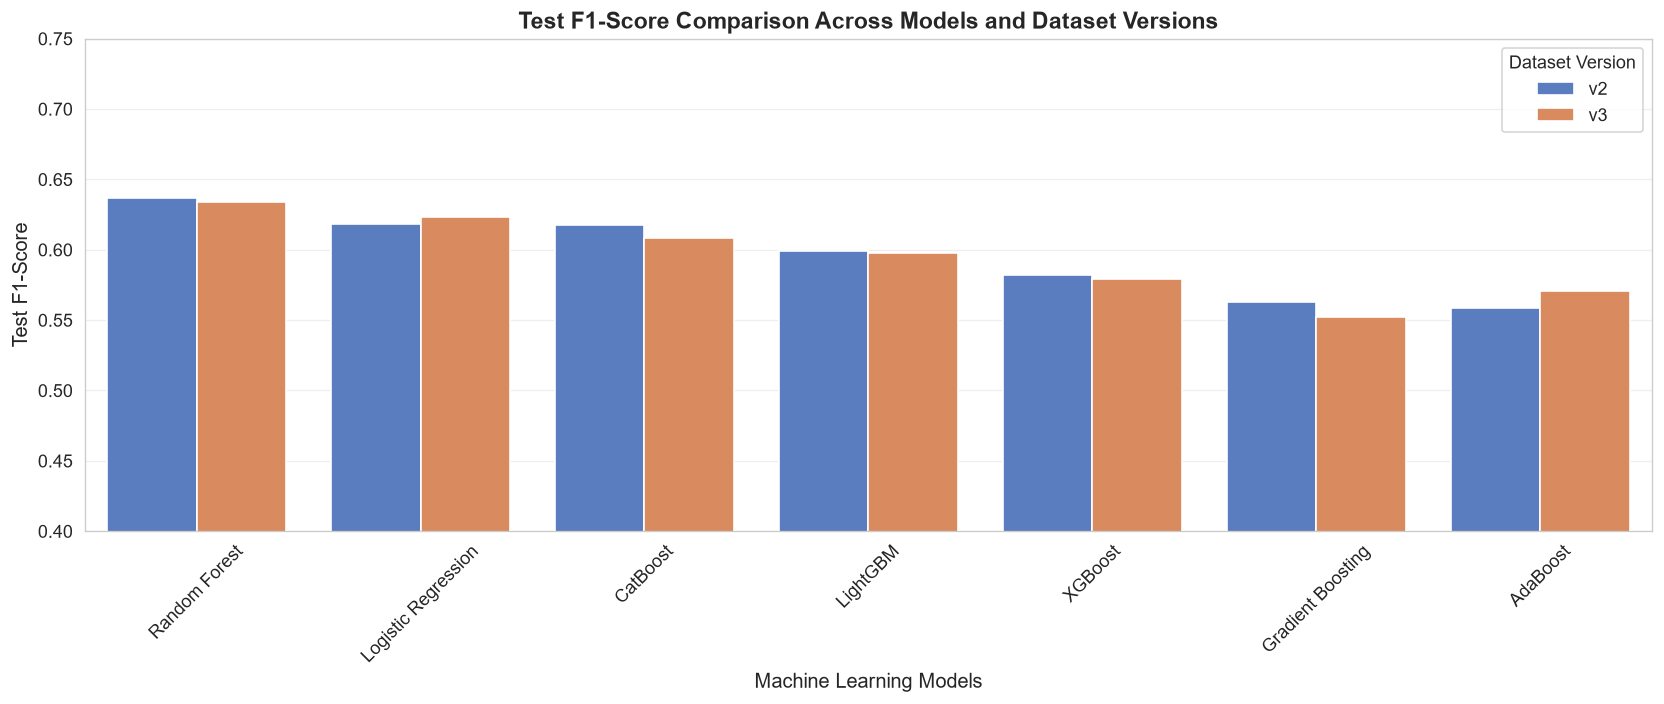

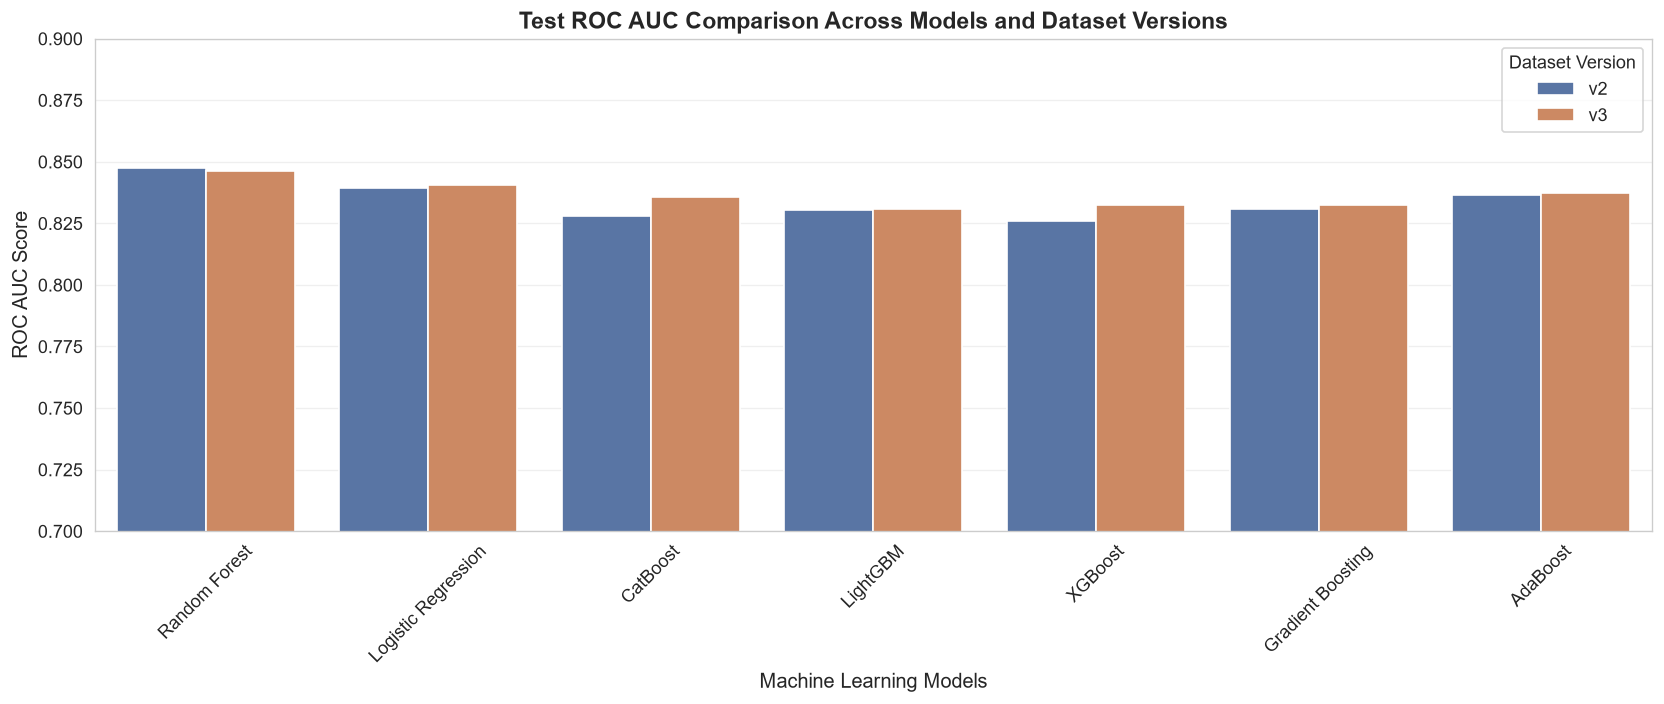

In [67]:
# Plot Test F1-Score Comparison
plt.figure(figsize=(14, 6))
sns.barplot(
    data=results_df, 
    x="Model", 
    y="Test F1", 
    hue="Dataset", 
    palette="muted"
)
plt.title("Test F1-Score Comparison Across Models and Dataset Versions")
plt.xlabel("Machine Learning Models")
plt.ylabel("Test F1-Score")
plt.ylim(0.4, 0.75)
plt.xticks(rotation=45)
plt.legend(title="Dataset Version")
plt.tight_layout()
plt.show()

# Plot Test ROC AUC Comparison
plt.figure(figsize=(14, 6))
sns.barplot(
    data=results_df, 
    x="Model", 
    y="Test ROC AUC", 
    hue="Dataset", 
    palette="deep"
)
plt.title("Test ROC AUC Comparison Across Models and Dataset Versions")
plt.xlabel("Machine Learning Models")
plt.ylabel("ROC AUC Score")
plt.ylim(0.7, 0.9)
plt.xticks(rotation=45)
plt.legend(title="Dataset Version")
plt.tight_layout()
plt.show()

### **2. Precision-Recall Trade-off Analysis**
A common issue in Churn Prediction is having a high **Recall** but a low **Precision** (generating too many False Positives). Below, we create a scatter plot mapping Precision against Recall for all runs. This allows us to visually inspect which models achieve the most stable equilibrium near the top-right corner, moving us closer to our $\sim 70\%$ F1-Score objective.

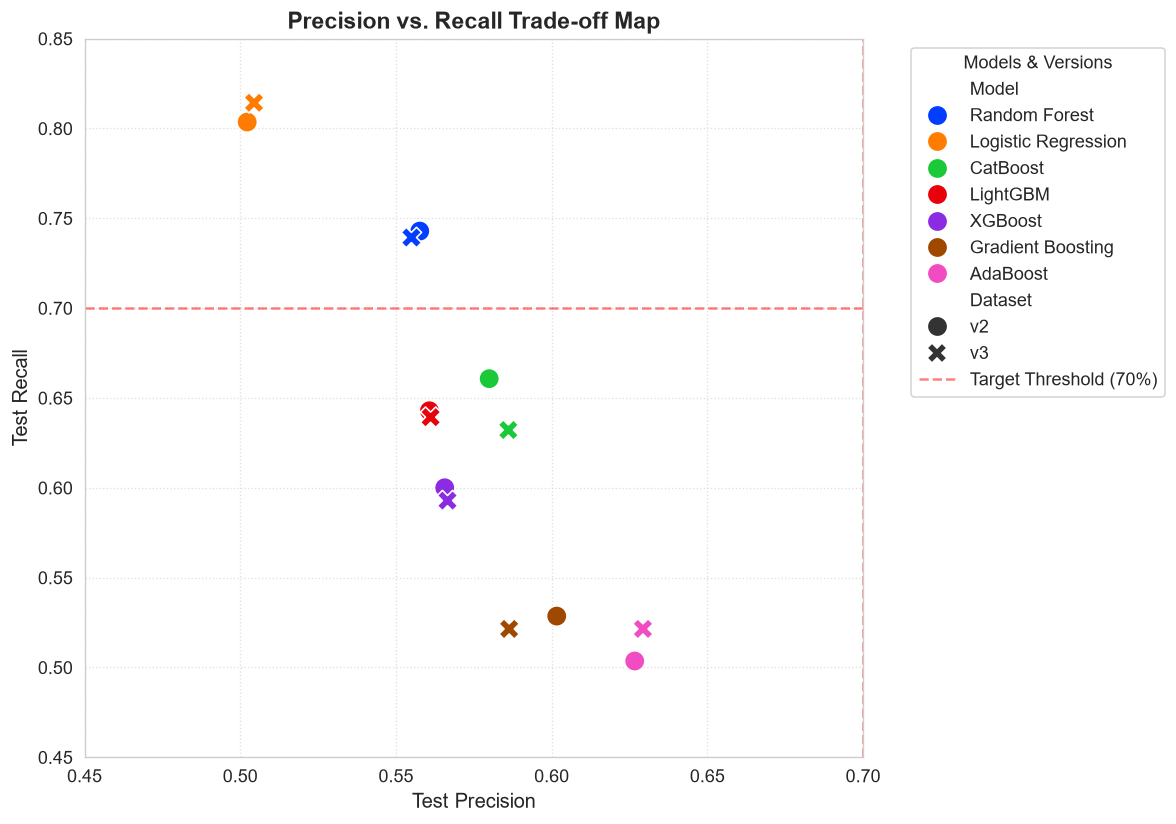

In [68]:
plt.figure(figsize=(10, 7))

# Create a scatter plot to analyze the trade-off
sns.scatterplot(
    data=results_df, 
    x="Test Precision", 
    y="Test Recall", 
    hue="Model", 
    style="Dataset", 
    s=150, 
    palette="bright"
)

# Reference line for target F1-Score region
plt.axhline(0.70, color='red', linestyle='--', alpha=0.5, label="Target Threshold (70%)")
plt.axvline(0.70, color='red', linestyle='--', alpha=0.5)

plt.title("Precision vs. Recall Trade-off Map")
plt.xlabel("Test Precision")
plt.ylabel("Test Recall")
plt.xlim(0.45, 0.70)
plt.ylim(0.45, 0.85)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Models & Versions")
plt.grid(True, linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()

### **3. Comprehensive Analysis of the Best Model**
Based on the experimental tracking data logged via MLflow, the **Random Forest** classifier trained on the **v2** dataset configuration currently achieves the most robust balance, yielding an F1-Score of **0.6309**. 
To better understand its micro-level behavior and identify where misclassifications happen, we extract the logged Confusion Matrix values (`TN`, `FP`, `FN`, `TP`) from MLflow data and render a visual heatmap.

Retrieving Confusion Matrix for Best Run: Random Forest (v2)


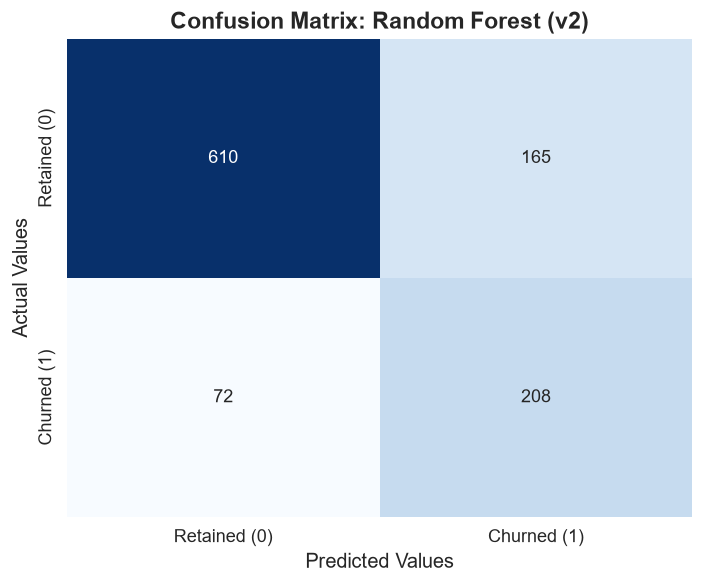

In [69]:
# Find the best run based on Test F1 Score
best_run = results_df.iloc[0]
best_model_name = best_run["Model"]
best_dataset_version = best_run["Dataset"]
best_run_id = best_run["Run ID"]

print(f"Retrieving Confusion Matrix for Best Run: {best_model_name} ({best_dataset_version})")

# Fetch metrics from MLflow using the active tracking backend
try:
    run_data = mlflow.get_run(best_run_id)
    metrics = run_data.data.metrics
    
    # Reconstruct Confusion Matrix array
    cm_array = np.array([
        [int(metrics.get("test_cm_tn", 0)), int(metrics.get("test_cm_fp", 0))],
        [int(metrics.get("test_cm_fn", 0)), int(metrics.get("test_cm_tp", 0))]
    ])
    
    # Plot the Heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        cm_array, 
        annot=True, 
        fmt="d", 
        cmap="Blues", 
        cbar=False,
        xticklabels=["Retained (0)", "Churned (1)"],
        yticklabels=["Retained (0)", "Churned (1)"]
    )
    plt.title(f"Confusion Matrix: {best_model_name} ({best_dataset_version})")
    plt.ylabel("Actual Values")
    plt.xlabel("Predicted Values")
    plt.tight_layout()
    plt.show()

except Exception as e:
    print(f"Could not automatically fetch from MLflow backend: {e}")
    print("Please ensure your MLflow server tracking URI is properly configured.")

In [71]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

def optimize_random_forest(X_train, y_train, cv_folds):
    def objective(trial):
        params = {
            'n_estimators': trial.suggest_int('n_estimators', 100, 1000, step=50),
            'max_depth': trial.suggest_int('max_depth', 5, 15),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 10),
            'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
            'class_weight': trial.suggest_categorical('class_weight', ['balanced', 'balanced_subsample', None]),
            'max_features': trial.suggest_categorical('max_features', ['sqrt', 'log2', None]),
            'random_state': 42,
            'n_jobs': -1
        }
        clf = RandomForestClassifier(**params)
        scores = cross_val_score(clf, X_train, y_train, cv=cv_folds, scoring='f1', n_jobs=-1)        
        return scores.mean()

    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=20, n_jobs=1)   
    return study.best_params, study.best_value


In [72]:
# Mian Loop for trianing with optuna
print("=" * 120)
print(
    f'{"Dataset":<8}'
    f'{"Model":<25}'
    f'{"CV F1":>10}'
    f'{"Test Acc":>10}'
    f'{"Precision":>10}'
    f'{"Recall":>10}'
    f'{"F1":>10}'
    f'{"ROC AUC":>10}'
    f'{"Time":>10}'
)
print("=" * 120)

optuna_results = []

for dataset_name, data in DATASETS.items():
    X_train = data["X_train"]
    X_test = data["X_test"]
    y_train = data["y_train"]
    y_test = data["y_test"]
    preprocessor = preprocessor_v2 if dataset_name == "v2" else preprocessor_v3
    X_train_transformed = preprocessor.fit_transform(X_train)
    X_test_transformed = preprocessor.transform(X_test)
    
    start_time = time.time()
    print(f"Running Optuna Optimization for Random Forest on {dataset_name}...")
    best_params, best_cv_f1 = optimize_random_forest(X_train_transformed, y_train, cv)
    best_rf_model = RandomForestClassifier(**best_params)
    
    run_name = f"random_forest_{dataset_name}_optuna_optimized"
    with mlflow.start_run(run_name=run_name):
        full_pipeline = SkiPipeline([('preprocessor', preprocessor), ('classifier', best_rf_model)])
        full_pipeline.fit(X_train, y_train)
        y_pred = full_pipeline.predict(X_test)
        y_prob = full_pipeline.predict_proba(X_test)[:, 1]
        test_acc = accuracy_score(y_test, y_pred)
        test_prec = precision_score(y_test, y_pred)
        test_rec = recall_score(y_test, y_pred)
        test_f1 = f1_score(y_test, y_pred)
        test_auc = roc_auc_score(y_test, y_prob)
        cm = confusion_matrix(y_test, y_pred)
        
        elapsed = time.time() - start_time
        
        mlflow.log_param("dataset", dataset_name)
        mlflow.log_param("model_name", "Random Forest (Optuna)")
        mlflow.log_param("optimization_method", "Optuna")
        mlflow.log_param("train_samples", len(X_train))
        mlflow.log_param("test_samples", len(X_test))
        
        for param_name, param_val in best_params.items():
            mlflow.log_param(f"optuna_best_{param_name}", param_val)
            
        mlflow.log_metric("cv_f1_mean", best_cv_f1)
        mlflow.log_metric("test_accuracy", test_acc)
        mlflow.log_metric("test_precision", test_prec)
        mlflow.log_metric("test_recall", test_rec)
        mlflow.log_metric("test_f1", test_f1)
        mlflow.log_metric("test_roc_auc", test_auc)
        mlflow.log_metric("training_time_sec", elapsed)
        
        mlflow.log_metric("test_cm_tn", int(cm[0, 0]))
        mlflow.log_metric("test_cm_fp", int(cm[0, 1]))
        mlflow.log_metric("test_cm_fn", int(cm[1, 0]))
        mlflow.log_metric("test_cm_tp", int(cm[1, 1]))
        
        artifact_name = f"random_forest_{dataset_name}_optuna"
        mlflow.sklearn.log_model(sk_model=best_rf_model, name=artifact_name)
        
        optuna_results.append({
            "Dataset": dataset_name, 
            "Model": "Random Forest (Optuna)", 
            "CV F1": best_cv_f1,
            "Test Accuracy": test_acc, 
            "Test Precision": test_prec,
            "Test Recall": test_rec, 
            "Test F1": test_f1, 
            "Test ROC AUC": test_auc,
            "Training Time (s)": elapsed, 
            "Run ID": mlflow.active_run().info.run_id
        })
        
        print(
            f"{dataset_name:<8}"
            f"Random Forest (Optuna)   "
            f"{best_cv_f1:>10.4f}"
            f"{test_acc:>10.4f}"
            f"{test_prec:>10.4f}"
            f"{test_rec:>10.4f}"
            f"{test_f1:>10.4f}"
            f"{test_auc:>10.4f}"
            f"{elapsed:>10.2f}"
        )

print("=" * 120)
optuna_results_df = pd.DataFrame(optuna_results).sort_values(by=["Test F1"], ascending=False).reset_index(drop=True)
display(optuna_results_df)

Dataset Model                         CV F1  Test Acc Precision    Recall        F1   ROC AUC      Time
Running Optuna Optimization for Random Forest on v2...
v2      Random Forest (Optuna)       0.6516    0.7564    0.5274    0.7893    0.6323    0.8466    107.45
Running Optuna Optimization for Random Forest on v3...
v3      Random Forest (Optuna)       0.6484    0.7441    0.5113    0.8107    0.6271    0.8421    167.89


,Dataset,Model,CV F1,Test Accuracy,Test Precision,Test Recall,Test F1,Test ROC AUC,Training Time (s),Run ID
0,v2,Random Forest (Optuna),0.651610,0.756398,0.527446,0.789286,0.632332,0.846571,107.449505,4df924520b114d818b7259f3e569256c
1,v3,Random Forest (Optuna),0.648401,0.744076,0.511261,0.810714,0.627072,0.842106,167.893579,ddd21761233e498fb5bfca755ffd98a0


In [73]:
best_rf_model.fit(X_train_transformed, y_train)

y_prob_train = best_rf_model.predict_proba(X_train_transformed)[:, 1]
y_prob_test = best_rf_model.predict_proba(X_test_transformed)[:, 1]

thresholds = np.linspace(0.3, 0.7, 100)
best_thresh = 0.5
best_train_f1 = 0

for thresh in thresholds:
    preds_train = (y_prob_train >= thresh).astype(int)
    score = f1_score(y_train, preds_train)
    if score > best_train_f1:
        best_train_f1 = score
        best_thresh = thresh

print(f"🎯 Optimal Decision Threshold Found on Train Data: {best_thresh:.3f}")
final_test_preds = (y_prob_test >= best_thresh).astype(int)
final_f1 = f1_score(y_test, final_test_preds)
final_precision = precision_score(y_test, final_test_preds)
final_recall = recall_score(y_test, final_test_preds)
final_acc = accuracy_score(y_test, final_test_preds)

print("\n" + "="*50)
print("🚀 OPTIMIZED RESULTS WITH THRESHOLD TUNING")
print("="*50)
print(f"Adjusted Test Accuracy:  {final_acc:.4f}")
print(f"Adjusted Test Precision: {final_precision:.4f}")
print(f"Adjusted Test Recall:    {final_recall:.4f}")
print(f"🚀 FINAL TEST F1-SCORE:  {final_f1:.4f}")
print("="*50)

🎯 Optimal Decision Threshold Found on Train Data: 0.563

🚀 OPTIMIZED RESULTS WITH THRESHOLD TUNING
Adjusted Test Accuracy:  0.7630
Adjusted Test Precision: 0.5377
Adjusted Test Recall:    0.7643
🚀 FINAL TEST F1-SCORE:  0.6313
